# FashionIQ
## Exploratory Data Analysis (Notebook 03)

**Project**: FashionIQ — End-to-End Fashion Sales Analytics

**Goal**: Investigate the cleaned dataset through a sequence of business-motivated questions, each answered with a clearly defined metric, evidence, and an honest interpretation of what the evidence does and does not support.

**Scope constraints**: No permanent feature engineering, no dashboard design, no business recommendations. This notebook produces validated patterns and open questions — the *Business Insights* stage (next) is where those questions get turned into recommendations.

---
## Project Metadata

- **Notebook**: `03_eda.ipynb`
- **Project**: FashionIQ
- **Version**: 1.0 (Part 1 — Sections 1–8: foundation, overall sales performance, order status)
- **Date**: 2026-08-02
- **Input**: `data/processed/fashion_sales_clean.csv` (read-only in this notebook)
- **Upstream notebooks**: `01_data_understanding.ipynb`, `02_data_cleaning.ipynb`

> **Note on scope**: this pass builds the analytical foundation (Sections 1–8) before moving on. Platform, geographic, product, category, rating, discount, and order-economics analysis (Sections 9–19) are built in a follow-up pass on top of the grain and metric definitions established here.

---
## Business Context

FashionIQ is a multi-platform Indonesian fashion retailer (5 platforms, 38 cities, 20 product types, 29 material variants). The cleaned dataset covers one calendar year (2025) of order-item level transactions.

Before this notebook produces a single chart, three data-semantics facts need to be treated as hard constraints, because getting them wrong invalidates almost every metric downstream:

1. **The dataset is order-item grain.** One row = one product line inside an order, not one order. `len(df)` counts line items, never orders.
2. **Some fields are order-level attributes duplicated across every line of an order** (e.g. `Shipping Fee`, `Grand Total`). Summing them directly at the row level double- (or quadruple-) counts them.
3. **Order Status is not a data quality issue — it's information.** Roughly 31% of orders are not `Completed`. Their financial values are still real numbers in the dataset, but calling `SUM(Total Sales)` "revenue" without qualification would overstate what actually converted into delivered, paid transactions.

This notebook treats every one of these as something to verify against the actual file, not assume from the brief.

---
## Notebook Objectives

- [ ] Confirm the cleaned dataset matches the state validated in `02_data_cleaning.ipynb`
- [ ] Establish and document the dataset's grain, including which fields are genuinely order-level vs. item-level
- [ ] Define every metric used in this notebook explicitly, before using it
- [ ] Answer: how large is recorded sales activity, and how does it move over the year?
- [ ] Answer: how does order status composition affect how "sales" should be read?
- [ ] Surface open, evidence-backed questions to carry into the next EDA pass (platform, geography, product, category, rating, discount, order economics)

---
## Load Clean Dataset

*Why*: this notebook reads exclusively from `data/processed/`. The raw file is never touched here, and no cleaning is repeated — `02_data_cleaning.ipynb` already validated that this file has zero missing values, zero duplicates, and consistent financial formulas.

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


def resolve_processed_path(filename: str = 'fashion_sales_clean.csv',
                            project_dir_name: str = 'fashion-sales-analytics-pipeline') -> Path:
    """Locate data/processed/<filename> regardless of the notebook's working directory.

    Jupyter/VS Code can launch a kernel with the working directory set to the
    notebook's own folder, the project root, or an unrelated workspace folder
    that merely contains this project -- so a single relative path such as
    '../data/processed/...' is not portable across machines or editors.

    Search order (project-root discovery, not a fixed list of guesses):
      1. The current working directory and every one of its parents, for a
         directory that directly contains 'data/processed/<filename>'.
         Covers running from the project root or from notebooks/.
      2. The current working directory and every one of its parents, for a
         '<project_dir_name>' subfolder containing 'data/processed/<filename>'.
         Covers an editor whose working directory is a workspace root that
         contains this project as a subdirectory.
    """
    marker = Path('data') / 'processed' / filename
    cwd = Path.cwd().resolve()
    search_dirs = [cwd, *cwd.parents]

    for candidate in search_dirs:
        direct = candidate / marker
        if direct.exists():
            return direct

    for candidate in search_dirs:
        nested = candidate / project_dir_name / marker
        if nested.exists():
            return nested

    raise FileNotFoundError(
        f"Could not locate '{marker}' by searching upward from '{cwd}', "
        f"including inside a '{project_dir_name}' subfolder. "
        f"Make sure this notebook is being run from within the FashionIQ project."
    )


PROCESSED_PATH = resolve_processed_path()
df = pd.read_csv(PROCESSED_PATH, parse_dates=['Order Date'])
print(f'Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Resolved path: {PROCESSED_PATH}')

Loaded dataset: 15,000 rows x 20 columns
Resolved path: C:\Users\ASUS GAMING\VSCode\fashion-sales-analytics-pipeline\data\processed\fashion_sales_clean.csv


**Shared utility functions**: two small helpers are used repeatedly across this notebook (both here and in the follow-up pass), so they're defined once, up front, instead of being rewritten inline each time.

In [2]:
def monthly_trend(data: pd.DataFrame, value_col: str, date_col: str = 'Order Date', how: str = 'sum') -> pd.Series:
    """Aggregate a column to monthly granularity. Used for time-based trend questions."""
    tmp = data.copy()
    tmp['_month'] = tmp[date_col].dt.to_period('M')
    return tmp.groupby('_month')[value_col].agg(how)


def summarize_by_dimension(order_level_df: pd.DataFrame, dimension: str,
                            sales_col: str = 'Total_Sales', order_id_col: str = 'Order ID') -> pd.DataFrame:
    """Break sales down into orders / total sales / AOV / sales share for a given order-level dimension.

    Used throughout this notebook to avoid the common mistake of ranking a dimension
    (platform, city, status, ...) by total sales alone without also checking whether
    that ranking is volume-driven or basket-value-driven.
    """
    summary = (order_level_df.groupby(dimension)
               .agg(orders=(order_id_col, 'nunique'), total_sales=(sales_col, 'sum'))
               .reset_index())
    summary['aov'] = (summary['total_sales'] / summary['orders']).round(0)
    summary['sales_share_pct'] = (summary['total_sales'] / summary['total_sales'].sum() * 100).round(1)
    return summary.sort_values('total_sales', ascending=False).reset_index(drop=True)


def rupiah_axis(ax, axis: str = 'y') -> None:
    """Format an axis in millions of Rupiah for readability on charts."""
    formatter = mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}M')
    (ax.yaxis if axis == 'y' else ax.xaxis).set_major_formatter(formatter)

---
## Initial EDA Inspection

### 5.1 Dataset shape

In [3]:
baseline_shape = (15000, 20)
assert df.shape == baseline_shape, f'Shape differs from Notebook 02 baseline: {df.shape}'
print('Shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))
print('Full-row duplicates:', int(df.duplicated().sum()))

Shape: (15000, 20)
Missing values: 0
Full-row duplicates: 0


### 5.2 Data types

In [4]:
print(df.dtypes)

Order ID                      str
Order Date         datetime64[us]
Customer Name                 str
City                          str
Product Name                  str
Unit Price                  int64
Quantity                    int64
Discount (%)                int64
Subtotal                    int64
Discount Amount             int64
Total Sales                 int64
Shipping Fee                int64
Grand Total                 int64
Payment Method                str
Order Status                  str
Platform                      str
Customer Rating             int64
Size                          str
Material                      str
Gender                        str
dtype: object


**Observation**: all 6 financial columns are numeric (`int64`) and `Order Date` is `datetime64`, as established in `02_data_cleaning.ipynb`. No type corrections are needed in this notebook.

### 5.3 Dataset grain

**Business question**: is this dataset one row per order, or one row per product line? Getting this wrong silently breaks every "total" computed later.

**Investigation**: check whether `Order ID` values repeat, and — critically — *which* columns stay constant within an `Order ID` (order-level attributes) vs. which vary (line-item attributes).

In [5]:
rows_per_order = df.groupby('Order ID').size()
print('Unique Order ID:', df['Order ID'].nunique())
print('Rows per order — distribution:')
print(rows_per_order.value_counts().sort_index())
print()
print('=> Confirms order-item grain: each order spans 2-4 product lines.')

Unique Order ID: 5000
Rows per order — distribution:
2    1500
3    2000
4    1500
Name: count, dtype: int64

=> Confirms order-item grain: each order spans 2-4 product lines.


In [6]:
candidate_order_level_cols = ['Order Date', 'Customer Name', 'City', 'Payment Method',
                              'Order Status', 'Platform', 'Shipping Fee', 'Grand Total', 'Customer Rating']

print('Constant within Order ID? (True = order-level attribute)')
for c in candidate_order_level_cols:
    is_constant = (df.groupby('Order ID')[c].nunique() == 1).all()
    print(f'  {c:16s} -> {is_constant}')

item_level_cols = ['Product Name', 'Unit Price', 'Quantity', 'Discount (%)',
                   'Subtotal', 'Discount Amount', 'Total Sales', 'Size', 'Material', 'Gender']
print()
print('Varies within Order ID at least once? (True = genuinely item-level)')
for c in item_level_cols:
    varies = (df.groupby('Order ID')[c].nunique() > 1).any()
    print(f'  {c:16s} -> {varies}')

Constant within Order ID? (True = order-level attribute)
  Order Date       -> True
  Customer Name    -> True
  City             -> True
  Payment Method   -> True
  Order Status     -> True
  Platform         -> True
  Shipping Fee     -> True
  Grand Total      -> True
  Customer Rating  -> True

Varies within Order ID at least once? (True = genuinely item-level)
  Product Name     -> True
  Unit Price       -> True
  Quantity         -> True
  Discount (%)     -> False
  Subtotal         -> True


  Discount Amount  -> True
  Total Sales      -> True
  Size             -> True
  Material         -> True
  Gender           -> True


**Evidence**: every field in `candidate_order_level_cols` is constant within an `Order ID` — including `Customer Rating`. This is worth flagging explicitly: `Customer Rating` is *not* a per-product rating despite sitting on every line item — it's a single rating attached to the whole order, repeated across its lines. Treating it as a product-level signal later (Section 13, next pass) would need line-item de-duplication first, or every multi-line order would over-count its own rating.

**Decision**: build one reusable order-level view (`order_df`, one row per `Order ID`) for every metric that is genuinely order-level — `Shipping Fee`, `Grand Total`, `Order Status`, `Customer Rating`, and order counts. Item-level metrics (`Quantity`, `Total Sales`, `Material`, category mix, etc.) stay on the line-item `df` and get summed *up to* the order level only when a question specifically needs that.

In [7]:
order_df = (
    df.groupby('Order ID')
      .agg(
          Order_Date=('Order Date', 'first'),
          Customer_Name=('Customer Name', 'first'),
          City=('City', 'first'),
          Platform=('Platform', 'first'),
          Payment_Method=('Payment Method', 'first'),
          Order_Status=('Order Status', 'first'),
          Customer_Rating=('Customer Rating', 'first'),
          Shipping_Fee=('Shipping Fee', 'first'),
          Grand_Total=('Grand Total', 'first'),
          Total_Sales=('Total Sales', 'sum'),
          Quantity=('Quantity', 'sum'),
          Line_Items=('Product Name', 'count'),
      )
      .reset_index()
)

# Validation: Grand Total should equal Total_Sales (summed) + Shipping Fee for every order
# (already proven in 02_data_cleaning.ipynb; re-confirmed here since order_df is newly built).
grand_total_check = (order_df['Grand_Total'] != (order_df['Total_Sales'] + order_df['Shipping_Fee'])).sum()
assert grand_total_check == 0, 'Grand Total no longer reconciles with Total Sales + Shipping Fee.'

print('order_df shape:', order_df.shape, '(one row per order, as expected)')
print('Grand Total reconciliation mismatches:', grand_total_check)
display(order_df.head(3))

order_df shape: (5000, 13) (one row per order, as expected)
Grand Total reconciliation mismatches: 0


,Order ID,Order_Date,Customer_Name,City,Platform,Payment_Method,Order_Status,Customer_Rating,Shipping_Fee,Grand_Total,Total_Sales,Quantity,Line_Items
0,ORD00001,2025-12-13 16:02:00,Clara Ananda,Pontianak,Toko Fashion App,Transfer Bank,Completed,3,17000,883000,866000,4,2
1,ORD00002,2025-10-28 13:57:00,Qori Syahputra,Manokwari,StyleMart,e-Wallet,Completed,2,24000,2228000,2204000,5,3
2,ORD00003,2025-12-09 19:16:00,Lestari Setiawan,Banjarbaru,Toko Fashion App,e-Wallet,Returned,5,24000,2122000,2098000,4,3


### 5.4 Date coverage

In [8]:
print('Date range:', df['Order Date'].min(), 'to', df['Order Date'].max())
print('Distinct calendar days with at least one order:', df['Order Date'].dt.date.nunique())
print('Months covered:', df['Order Date'].dt.to_period('M').nunique())

Date range: 2025-01-01 08:49:00 to 2025-12-31 17:23:00
Distinct calendar days with at least one order: 365
Months covered: 12


**Observation**: coverage is exactly one calendar year (Jan–Dec 2025). This matters for later sections: with only one year of data, month-over-month fluctuation can be described, but **recurring seasonality cannot be established** — that requires comparable months across multiple years. This notebook will describe monthly patterns as *fluctuation*, not *seasonality*, unless multi-year data becomes available.

### 5.5 Cardinality

In [9]:
card = df.nunique(dropna=False).sort_values(ascending=False)
display(card.to_frame('unique_values'))

,unique_values
Order ID,5000
Order Date,4966
Grand Total,2144
Total Sales,1511
Subtotal,1124
Unit Price,818
Discount Amount,455
Customer Name,395
City,38
Material,29


**Observation**: `Customer Name` has 395 unique values, but as established in `01_data_understanding.ipynb`, there is no `Customer ID` and the same name spans multiple cities for the large majority of names. Any figure derived from `Customer Name` is reported as **"unique customer-name values,"** never as a customer count, and customer-level analysis stays a minor, clearly caveated angle rather than a core section of this EDA.

### 5.6 Numerical summary

In [10]:
numeric_cols = ['Unit Price', 'Quantity', 'Discount (%)', 'Subtotal', 'Discount Amount',
                'Total Sales', 'Shipping Fee', 'Grand Total', 'Customer Rating']
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Unit Price,15000.0,2.895617e+05,151076.605508,39000.0,184000.0,264000.0,363000.0,897000.0
Quantity,15000.0,1.763533e+00,0.818654,1.0,1.0,2.0,2.0,4.0
Discount (%),15000.0,4.813333e-01,2.140551,0.0,0.0,0.0,0.0,10.0
Subtotal,15000.0,4.673213e+05,251200.032945,39000.0,278000.0,418500.0,613000.0,1598000.0
Discount Amount,15000.0,2.267640e+03,11466.046464,0.0,0.0,0.0,0.0,156800.0
Total Sales,15000.0,4.650536e+05,250240.375963,39000.0,276000.0,417000.0,610000.0,1598000.0
Shipping Fee,15000.0,2.383800e+04,3355.469159,17000.0,22000.0,24000.0,27000.0,27000.0
Grand Total,15000.0,1.512122e+06,561762.103012,227000.0,1100000.0,1479000.0,1873000.0,3943000.0
Customer Rating,15000.0,2.968667e+00,1.408196,1.0,2.0,3.0,4.0,5.0


**Observation**: `Discount (%)` ranges from 0 up, meaning not every line item carries a discount — this is investigated properly in the discount section of the next pass. `Customer Rating` sits on a 1–5 scale, consistent with the data dictionary from Notebook 01.

### 5.7 Metric definitions

These definitions are fixed for the rest of this notebook (and the follow-up pass), to avoid redefining "sales" or "AOV" differently in different sections.

| Metric | Definition | Grain |
|---|---|---|
| **Item rows** | `len(df)` | line-item |
| **Units sold** | `df['Quantity'].sum()` | line-item, summable |
| **Order count** | `df['Order ID'].nunique()` | order |
| **Recorded sales** | `df['Total Sales'].sum()` — summed at line level, valid because `Total Sales` is genuinely a per-line value | line-item, summable |
| **Sales AOV** | `Recorded sales / Order count` — excludes shipping | order |
| **Order-level Grand Total** | `mean(order_df['Grand_Total'])` — includes shipping, requires the order-level view (never `df['Grand Total'].sum()`) | order |

"Recorded sales" is used deliberately instead of "revenue" throughout — Section 8 shows why.

---
## EDA Analysis Plan

This pass covers the foundation and the two sections that every later question depends on:

1. **Overall Sales Performance** (Section 7) — establishes the scale and time trend of the business before slicing it by any dimension.
2. **Order Status** (Section 8) — establishes how much of "recorded sales" is actually safe to treat as realized activity, which changes how every later platform/geography/product breakdown should be read.

The follow-up pass builds Sections 9–19 (platform, geography, product, category/material/gender, rating, discount, order economics, cross-dimensional analysis, and findings) on top of the grain, metric definitions, and status caveats established here.

---
## 7. Overall Sales Performance

### 7.1 Business scale

**Business question**: at a glance, how big is this business in the dataset — how much recorded sales, how many orders, how many units?

**Metric**: item rows, order count, units sold, recorded sales, and Sales AOV, all as defined in 5.7.

In [11]:
item_rows = len(df)
order_count = df['Order ID'].nunique()
units_sold = int(df['Quantity'].sum())
recorded_sales = int(df['Total Sales'].sum())
sales_aov = recorded_sales / order_count
grand_total_aov = order_df['Grand_Total'].mean()

print(f'Item rows (line-item grain):     {item_rows:,}')
print(f'Order count:                     {order_count:,}')
print(f'Units sold:                       {units_sold:,}')
print(f'Recorded sales (Total Sales sum): Rp {recorded_sales:,}')
print(f'Sales AOV (excl. shipping):       Rp {sales_aov:,.0f}')
print(f'Order-level Grand Total AOV:      Rp {grand_total_aov:,.0f}')
print(f'Avg. line items per order:        {item_rows/order_count:.2f}')
print(f'Avg. units per order:              {units_sold/order_count:.2f}')

Item rows (line-item grain):     15,000
Order count:                     5,000
Units sold:                       26,453
Recorded sales (Total Sales sum): Rp 6,975,804,400
Sales AOV (excl. shipping):       Rp 1,395,161
Order-level Grand Total AOV:      Rp 1,418,186
Avg. line items per order:        3.00
Avg. units per order:              5.29


**Observation**: the average order contains 3.0 line items and about 5.3 units, generating a Sales AOV of roughly Rp 1.40 million (excluding shipping) or Rp 1.42 million including shipping (Grand Total). The two AOV figures are close — shipping fees are a small fraction of order value, not a major driver of order economics at this aggregate level.

**Interpretation**: the business appears to operate with multi-item baskets and moderate order value. Whether that is high or low cannot be judged from this dataset alone, because no external benchmark or prior period is available.

**Caveat**: `recorded_sales` includes all order statuses, including `Cancelled` and `Returned`. Section 8 quantifies exactly how much of this figure that represents before any of it gets treated as a performance metric.

### 7.2 Sales over time

**Business question**: does recorded sales activity fluctuate meaningfully across the year, and is there a clear upward or downward movement?

**Metric**: recorded sales, aggregated to monthly granularity (`monthly_trend` helper).

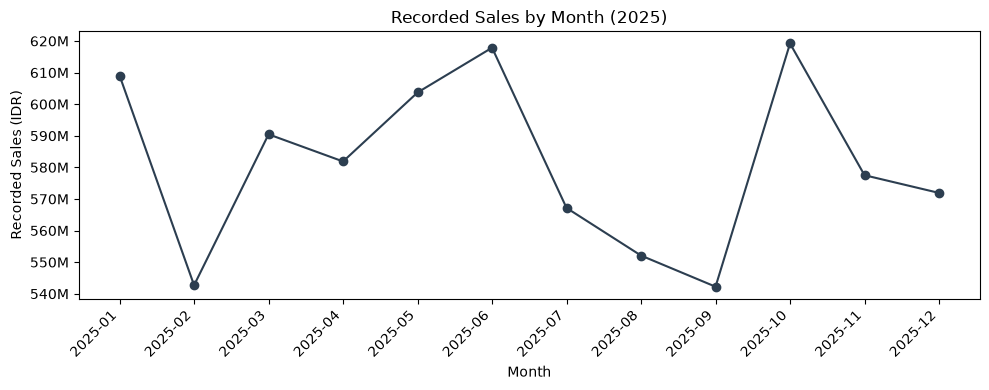

Monthly sales — mean: Rp 581,317,033, std: Rp 27,469,604, CoV: 4.7%
Highest month: 2025-10 (Rp 619,206,200)
Lowest month:  2025-09 (Rp 542,245,500)
Highest-to-lowest spread: 14.2%


In [12]:
monthly_sales = monthly_trend(df, 'Total Sales', how='sum')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', color='#2c3e50')
ax.set_title('Recorded Sales by Month (2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

sales_cov = monthly_sales.std() / monthly_sales.mean()
print(f'Monthly sales — mean: Rp {monthly_sales.mean():,.0f}, std: Rp {monthly_sales.std():,.0f}, CoV: {sales_cov:.1%}')
print(f'Highest month: {monthly_sales.idxmax()} (Rp {monthly_sales.max():,.0f})')
print(f'Lowest month:  {monthly_sales.idxmin()} (Rp {monthly_sales.min():,.0f})')
print(f'Highest-to-lowest spread: {(monthly_sales.max()/monthly_sales.min() - 1):.1%}')

**Observation**: monthly recorded sales range from about Rp 542M (September) to Rp 619M (October) — a coefficient of variation under 5%. There is no visible trend of sustained growth or decline across the year; the line moves within a narrow band around its mean.

**Interpretation**: sales activity is essentially flat across 2025 at the monthly level. October's mild peak and September's mild trough are the extremes, but a ~14% high-to-low spread on a single year of data is within a narrow range for this dataset — not a pattern that supports a growth or decline narrative.

**Caveat**: with only 12 months of data, this notebook cannot say whether October/September are *recurring* seasonal points (e.g. a pre-holiday bump) — that claim would require comparable months from at least one other year. This is intra-year fluctuation, not confirmed seasonality.

**Follow-up question**: does the same flatness hold for order count and units sold independently, or does a stable sales figure hide offsetting movements in order volume vs. basket size?

### 7.3 Orders over time

**Business question**: is the flat sales trend explained by a flat order count, or is order count moving while AOV offsets it?

**Metric**: order count, aggregated to monthly granularity from `order_df` (order-level, avoids re-counting line items).

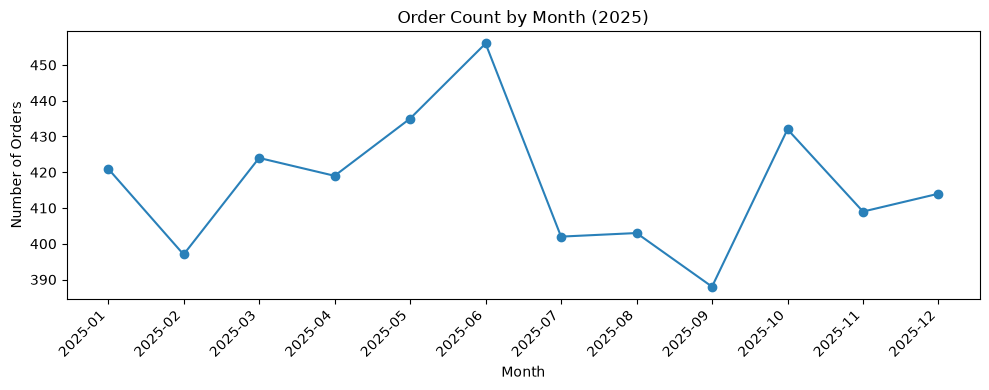

Monthly orders — mean: 417, std: 18.8, CoV: 4.5%
Highest month: 2025-06 (456 orders)
Lowest month:  2025-09 (388 orders)


In [13]:
monthly_orders = monthly_trend(order_df.rename(columns={'Order_Date': 'Order Date'}), 'Order ID', how='nunique')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_orders.index.astype(str), monthly_orders.values, marker='o', color='#2980b9')
ax.set_title('Order Count by Month (2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

orders_cov = monthly_orders.std() / monthly_orders.mean()
print(f'Monthly orders — mean: {monthly_orders.mean():.0f}, std: {monthly_orders.std():.1f}, CoV: {orders_cov:.1%}')
print(f'Highest month: {monthly_orders.idxmax()} ({monthly_orders.max()} orders)')
print(f'Lowest month:  {monthly_orders.idxmin()} ({monthly_orders.min()} orders)')

**Observation**: monthly order count ranges from 388 to 456 (CoV ~5%), tracking the same flat pattern as recorded sales — the months don't even rank identically (order count peaks in June, sales peaks in October), suggesting the two aren't tightly coupled month-to-month.

**Interpretation**: order volume is as stable as sales value across the year. Neither metric shows a trend a recruiter should describe as "growth."

**Caveat**: small monthly order counts (~400) mean month-to-month differences of 15-20 orders can look visually significant on a chart but represent a ~4-5% swing — worth stating plainly rather than letting the chart imply more than the number does.

### 7.4 Units sold over time

**Business question**: does the unit volume trend match the order-count trend, or does basket composition (units per order) shift across the year?

**Metric**: units sold (`Quantity` sum), aggregated to monthly granularity.

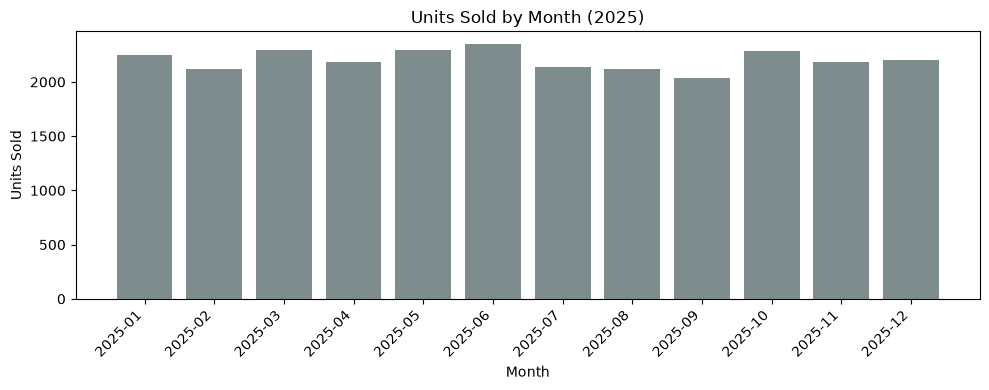

Units per order, by month:
_month
2025-01    5.34
2025-02    5.34
2025-03    5.41
2025-04    5.20
2025-05    5.28
2025-06    5.15
2025-07    5.33
2025-08    5.26
2025-09    5.24
2025-10    5.29
2025-11    5.35
2025-12    5.31
Freq: M, dtype: float64

Units-per-order range across the year: 5.15 to 5.41


In [14]:
monthly_units = monthly_trend(df, 'Quantity', how='sum')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_units.index.astype(str), monthly_units.values, color='#7f8c8d')
ax.set_title('Units Sold by Month (2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

units_per_order_monthly = (monthly_units / monthly_orders).round(2)
print('Units per order, by month:')
print(units_per_order_monthly)
print()
print(f'Units-per-order range across the year: {units_per_order_monthly.min()} to {units_per_order_monthly.max()}')

**Observation**: units sold per month move in the same narrow band as orders (as expected, since units and orders are structurally linked). Units-per-order stays close to ~5.3 in every month, with no month standing out as a materially different basket composition.

**Interpretation**: the business did not experience a period where customers bought unusually more or fewer items per order — whatever monthly variation exists in sales and orders is not being driven by basket-size shifts.

**Caveat**: this rules out one possible mechanism (basket-size change) behind the monthly sales fluctuation seen in 7.2, but does not identify what — if anything — does explain it. Given the CoV is under 5% throughout, the most defensible reading is that there simply isn't a strong mechanism to find; the fluctuation looks like ordinary noise.

### 7.5 AOV over time

**Business question**: is Sales AOV stable across the year, or does it swing independently of order count and units?

**Metric**: Sales AOV = monthly recorded sales / monthly order count.

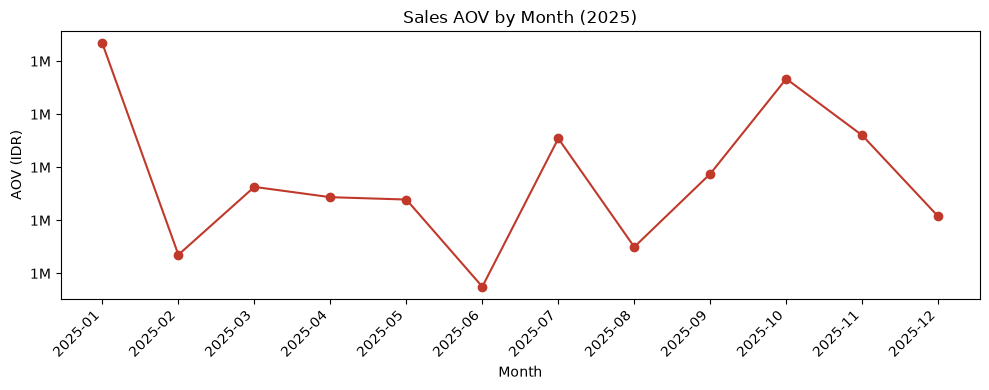

Monthly AOV — mean: Rp 1,395,248, std: Rp 26,931, CoV: 1.9%
Highest AOV month: 2025-01 (Rp 1,446,656)
Lowest AOV month:  2025-06 (Rp 1,354,981)


In [15]:
monthly_aov = (monthly_sales / monthly_orders).round(0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_aov.index.astype(str), monthly_aov.values, marker='o', color='#c0392b')
ax.set_title('Sales AOV by Month (2025)')
ax.set_xlabel('Month')
ax.set_ylabel('AOV (IDR)')
rupiah_axis(ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

aov_cov = monthly_aov.std() / monthly_aov.mean()
print(f'Monthly AOV — mean: Rp {monthly_aov.mean():,.0f}, std: Rp {monthly_aov.std():,.0f}, CoV: {aov_cov:.1%}')
print(f'Highest AOV month: {monthly_aov.idxmax()} (Rp {monthly_aov.max():,.0f})')
print(f'Lowest AOV month:  {monthly_aov.idxmin()} (Rp {monthly_aov.min():,.0f})')

**Observation**: monthly AOV ranges from about Rp 1.35M to Rp 1.45M — a CoV under 3%, the tightest band of any metric checked in this section.

**Interpretation**: AOV is the most stable of the four time-series checked (sales, orders, units, AOV). Combined with 7.2–7.4, the honest summary is: **no meaningful pattern was observed** in any monthly time series beyond ordinary fluctuation — this dataset does not show a growth story, a decline story, or a strong seasonal story at the monthly level.

**Caveat**: a single year of order-item data, viewed only at monthly granularity, is a limited lens. Weekly or day-of-week patterns, or a second year of data for genuine seasonality testing, could reveal structure this view can't.

**Follow-up question**: if none of the aggregate time trends are meaningful, do any *sub-groups* (specific platforms, cities, or products) show a real growth/decline pattern that's being averaged out at the whole-business level? This is a natural candidate for the cross-dimensional section in the next pass.

---
## 8. Order Status Analysis

### 8.1 Status distribution

**Business question**: what fraction of orders are actually `Completed`, and how much financial value sits outside that status?

**Metric**: order count and share by `Order Status`, computed on `order_df` (order-level, so each order is counted once regardless of its line-item count).

,orders,pct_of_orders
Order_Status,,
Completed,3430,68.6
Returned,694,13.9
Cancelled,371,7.4
Shipped,263,5.3
Pending,242,4.8


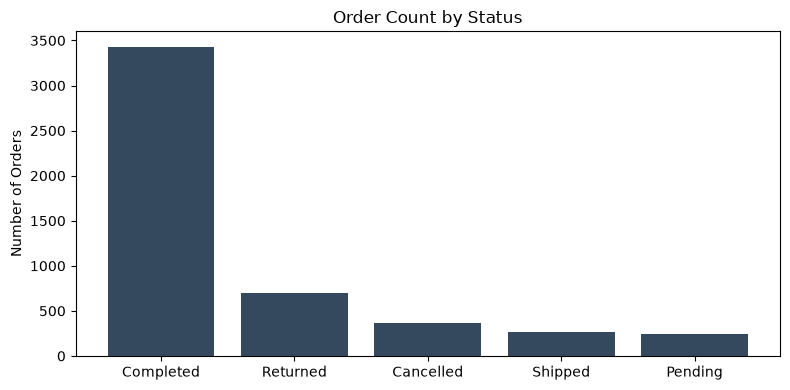

In [16]:
status_counts = order_df['Order_Status'].value_counts()
status_pct = (status_counts / status_counts.sum() * 100).round(1)
status_table = pd.DataFrame({'orders': status_counts, 'pct_of_orders': status_pct})
display(status_table)

fig, ax = plt.subplots(figsize=(8, 4))
order = status_table.index
ax.bar(order, status_table['orders'], color='#34495e')
ax.set_title('Order Count by Status')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**Observation**: `Completed` accounts for 68.6% of orders (3,430 of 5,000). The remaining 31.4% is split across `Returned` (13.9%), `Cancelled` (7.4%), `Shipped` (5.3%, i.e. in transit / not yet confirmed complete), and `Pending` (4.8%).

**Interpretation**: roughly one in three orders in this dataset has not reached a completed state. That's a large enough share that any "sales" figure computed without a status breakdown risks materially overstating realized business activity.

**Caveat**: this dataset provides no timestamp for status transitions, so it's not possible to tell whether `Pending`/`Shipped` orders will eventually convert to `Completed` or `Cancelled`/`Returned` — the status here is a snapshot, not a lifecycle.

### 8.2 Sales by status

**Business question**: does financial value concentrate in `Completed` orders proportionally to their order-count share, or do certain statuses carry disproportionate value?

**Metric**: recorded sales and average Grand Total, broken down by status using the `summarize_by_dimension` helper.

,status,orders,total_sales,aov,sales_share_pct
0,Completed,3430,4794773200,1397893.0,68.7
1,Returned,694,979337300,1411149.0,14.0
2,Cancelled,371,488457500,1316597.0,7.0
3,Shipped,263,362525900,1378425.0,5.2
4,Pending,242,350710500,1449217.0,5.0


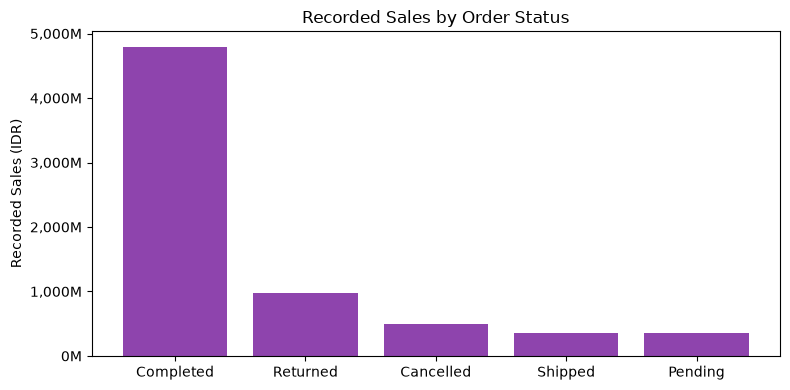

Average Grand Total by status:
Order_Status
Pending      1472556.0
Returned     1434150.0
Completed    1420918.0
Shipped      1401505.0
Cancelled    1339425.0
Name: Grand_Total, dtype: float64


In [17]:
status_summary = summarize_by_dimension(order_df, 'Order_Status')
status_summary = status_summary.rename(columns={'Order_Status': 'status'})
display(status_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(status_summary['status'], status_summary['total_sales'], color='#8e44ad')
ax.set_title('Recorded Sales by Order Status')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax)
plt.tight_layout()
plt.show()

print('Average Grand Total by status:')
print(order_df.groupby('Order_Status')['Grand_Total'].mean().round(0).sort_values(ascending=False))

**Observation**: sales share by status (68.7% Completed, 14.0% Returned, 7.0% Cancelled, 5.2% Shipped, 5.0% Pending) tracks the order-count share from 8.1 almost exactly — `Completed` is 68.6% of orders and 68.7% of sales. Average Grand Total is also nearly identical across every status (all cluster around Rp 1.4M).

**Interpretation**: order value does not vary meaningfully by status — a cancelled or returned order in this dataset is, on average, the same size as a completed one. This means the ~31% of sales sitting outside `Completed` isn't concentrated in unusually large or small transactions; it's a proportional cross-section of the whole order-value distribution.

**Caveat**: "no meaningful difference in average order value by status" is itself a finding worth stating plainly rather than searching for a pattern that isn't there — the data does not support a claim like "returned orders tend to be higher-value" or "cancelled orders tend to be smaller."

**Follow-up question**: is the ~31% non-completed share itself concentrated in specific platforms, cities, or products — even though it isn't concentrated in order value? That question is picked up in the platform and product sections of the next pass.

### 8.3 Completed vs. non-completed

**Business question**: for a cleaner top-line read, how does the business look if reduced to two groups — `Completed` vs. everything else?

In [18]:
order_df['status_group'] = np.where(order_df['Order_Status'] == 'Completed', 'Completed', 'Non-completed')
group_summary = summarize_by_dimension(order_df, 'status_group').rename(columns={'status_group': 'group'})
display(group_summary)

print(f"Recorded sales sitting in non-completed orders: {group_summary.loc[group_summary['group']=='Non-completed', 'sales_share_pct'].values[0]}% of total")

,group,orders,total_sales,aov,sales_share_pct
0,Completed,3430,4794773200,1397893.0,68.7
1,Non-completed,1570,2181031200,1389192.0,31.3


Recorded sales sitting in non-completed orders: 31.3% of total


**Observation**: 31.3% of recorded sales (Rp ~2.18B of Rp ~6.98B) sits in non-completed orders.

**Interpretation**: for any later section that reports a "sales" figure — platform performance, geographic performance, product performance — the same ~31% caveat applies uniformly. Rather than repeating a full status breakdown in every section, this notebook will use **"recorded sales"** as the default label everywhere, and will only add a `Completed`-only comparison where a specific finding seems to depend on order-status composition (per the cross-dimensional principle in Section 15 of the plan).

**Caveat**: this notebook does not treat `Cancelled`/`Returned` value as "lost revenue" either — that framing would assume every non-completed order would otherwise have converted at full value, which nothing in this dataset supports.

## 9. Platform Performance

This section compares platform performance on the same order-level dimensions used earlier: recorded sales, orders, AOV, units per order, discount behavior, and material mix.


Platform performance summary


,Platform,order_count,recorded_sales,aov,sales_share_pct,avg_units_per_order
0,Toko Fashion App,1753,2459498600,1403023.0,35.3,NaN
1,StyleMart,1134,1550422300,1367215.0,22.2,NaN
2,FashionKita,1000,1414191200,1414191.0,20.3,NaN
3,OutfitNow,658,923708300,1403812.0,13.2,NaN
4,FashionHub,455,627984000,1380185.0,9.0,NaN


Platform discount behavior


,Platform,avg_discount_rate,pct_discounted
0,FashionHub,0.0059,5.9
1,FashionKita,0.0056,5.6
2,OutfitNow,0.0051,5.1
3,StyleMart,0.0038,3.8
4,Toko Fashion App,0.0046,4.6


Top 5 materials by recorded sales within each platform


,Platform,Material,recorded_sales
8,FashionHub,Katun,90490700
16,FashionHub,Polyester,68488500
18,FashionHub,Satin,43911600
23,FashionHub,Sutra,38900300
24,FashionHub,Twill,32214800
37,FashionKita,Katun,180485000
45,FashionKita,Polyester,139781700
47,FashionKita,Satin,90917100
53,FashionKita,Twill,77204200
52,FashionKita,Sutra,73661500


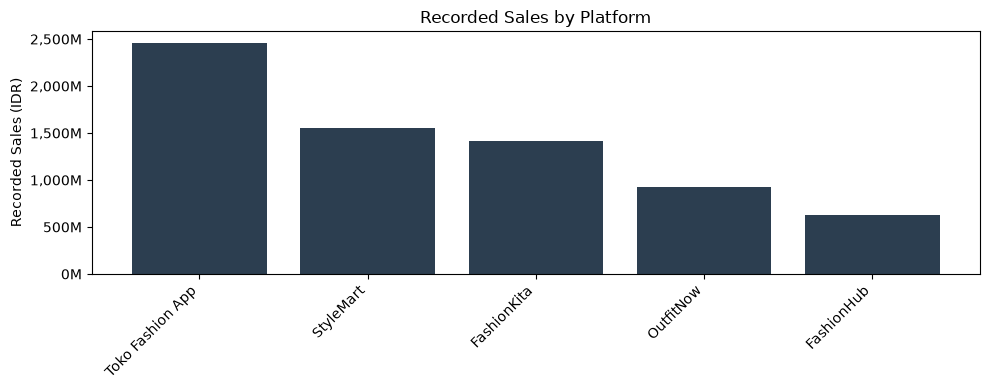

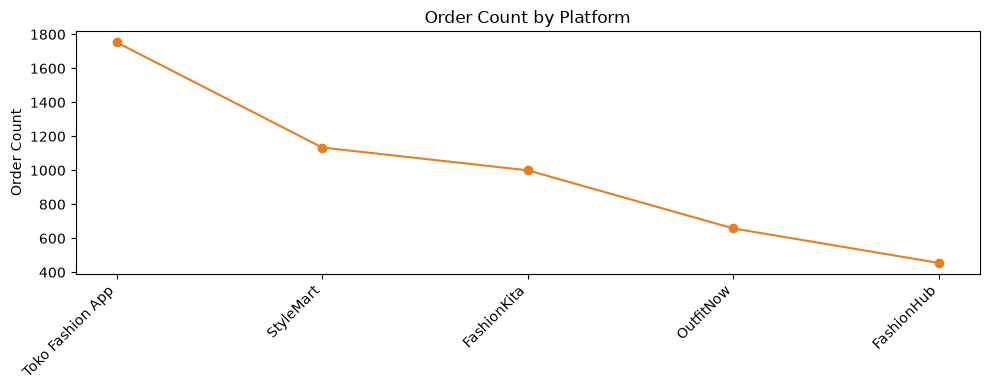

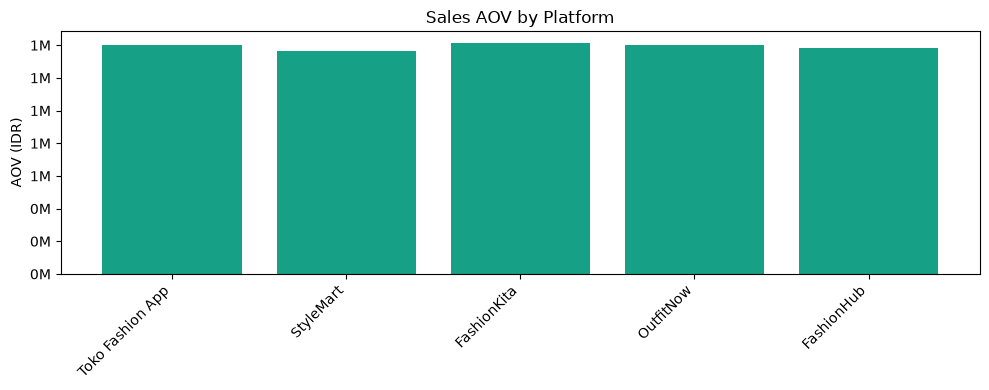

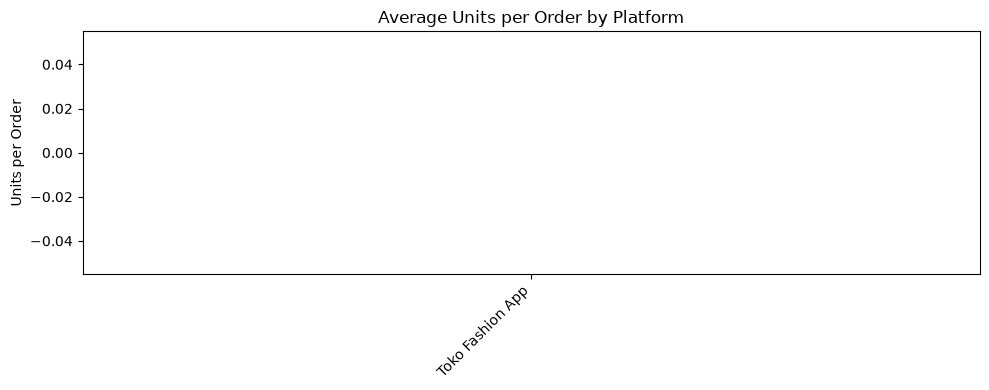

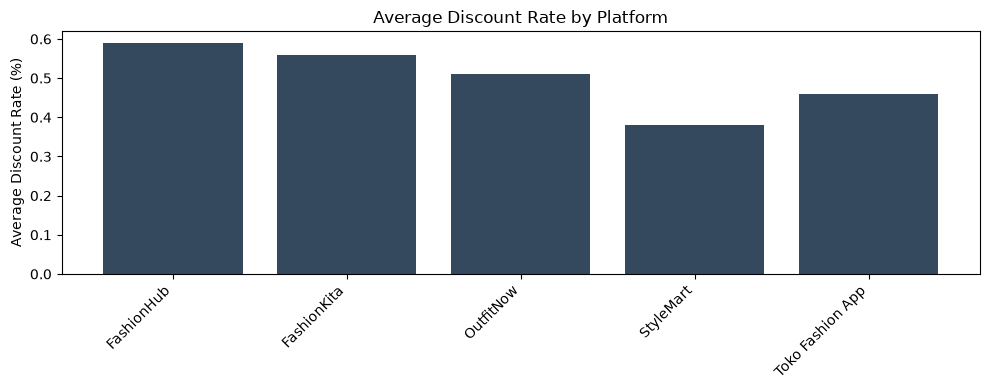

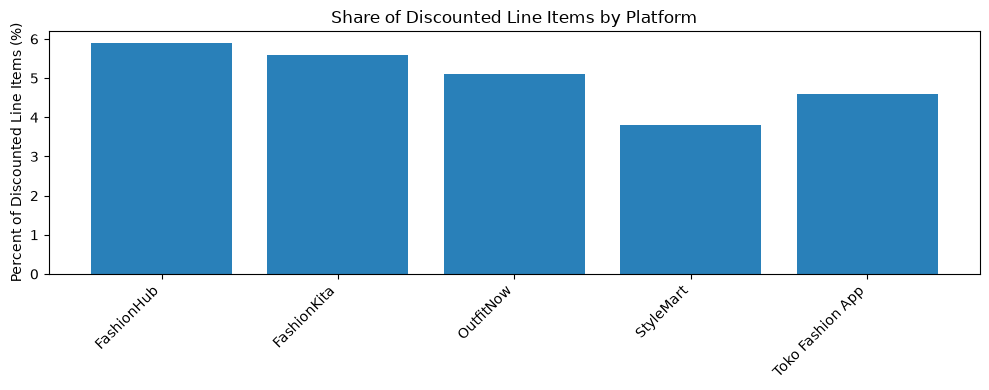

In [19]:
platform_summary = summarize_by_dimension(order_df, 'Platform').rename(
    columns={'orders': 'order_count', 'total_sales': 'recorded_sales'}
)
platform_summary['avg_units_per_order'] = (
    order_df.groupby('Platform')['Quantity'].sum() /
    order_df.groupby('Platform')['Order ID'].nunique()
).round(2)
platform_summary['aov'] = platform_summary['aov'].round(0)
platform_summary['recorded_sales'] = platform_summary['recorded_sales'].astype(int)

platform_discount = (
    df.assign(discount_rate=lambda x: x['Discount Amount'] / x['Subtotal'].replace(0, np.nan))
      .groupby('Platform')
      .agg(avg_discount_rate=('discount_rate', 'mean'),
           pct_discounted=('discount_rate', lambda x: (x > 0).mean() * 100))
      .reset_index()
)
platform_discount['avg_discount_rate'] = platform_discount['avg_discount_rate'].round(4)
platform_discount['pct_discounted'] = platform_discount['pct_discounted'].round(1)

platform_material_mix = (
    df.groupby(['Platform', 'Material'])
      .agg(recorded_sales=('Total Sales', 'sum'))
      .reset_index()
      .sort_values(['Platform', 'recorded_sales'], ascending=[True, False])
      .groupby('Platform')
      .head(5)
)

print('Platform performance summary')
display(platform_summary)
print('Platform discount behavior')
display(platform_discount)
print('Top 5 materials by recorded sales within each platform')
display(platform_material_mix)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(platform_summary['Platform'], platform_summary['recorded_sales'], color='#2c3e50')
ax.set_title('Recorded Sales by Platform')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(platform_summary['Platform'], platform_summary['order_count'], marker='o', color='#e67e22')
ax.set_title('Order Count by Platform')
ax.set_ylabel('Order Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(platform_summary['Platform'], platform_summary['aov'], color='#16a085')
ax.set_title('Sales AOV by Platform')
ax.set_ylabel('AOV (IDR)')
rupiah_axis(ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(platform_summary['Platform'], platform_summary['avg_units_per_order'], color='#8e44ad')
ax.set_title('Average Units per Order by Platform')
ax.set_ylabel('Units per Order')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(platform_discount['Platform'], platform_discount['avg_discount_rate'] * 100, color='#34495e')
ax.set_title('Average Discount Rate by Platform')
ax.set_ylabel('Average Discount Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(platform_discount['Platform'], platform_discount['pct_discounted'], color='#2980b9')
ax.set_title('Share of Discounted Line Items by Platform')
ax.set_ylabel('Percent of Discounted Line Items (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Interpretation**: Platform KPI metrics are evaluated at order level, while material mix is evaluated at line-item level because `Material` is an item-level attribute.

Toko Fashion App records the highest recorded sales and also the highest order count, while its AOV is similar to FashionKita and OutfitNow. This indicates that its platform sales leadership is primarily volume-driven rather than being driven by a substantially higher basket value.

FashionKita has one of the higher AOV figures, suggesting it achieves stronger basket value with fewer orders than the top sales platform. StyleMart and FashionHub have lower AOV despite moderate order volumes, so the platform differences are mixed: order volume appears more influential for the top position, while AOV contributes to mid-tier platform performance.

## 10. Geographic Performance

This section examines city-level performance using order-level metrics. The central question is whether high-sales cities owe their position to higher order volume, higher AOV, or both.

Top 10 cities by recorded sales


,City,order_count,recorded_sales,aov,sales_share_pct
0,Jakarta,252,338853800,1344658.0,4.9
1,Pangkalpinang,198,292496400,1477255.0,4.2
2,Semarang,199,284329600,1428792.0,4.1
3,Surabaya,197,268973300,1365347.0,3.9
4,Jayapura,190,267033900,1405442.0,3.8
5,Samarinda,198,263389100,1330248.0,3.8
6,Pontianak,180,255273400,1418186.0,3.7
7,Bandung,174,248107400,1425905.0,3.6
8,Wamena,163,231463100,1420019.0,3.3
9,Bengkulu,159,226642700,1425426.0,3.2


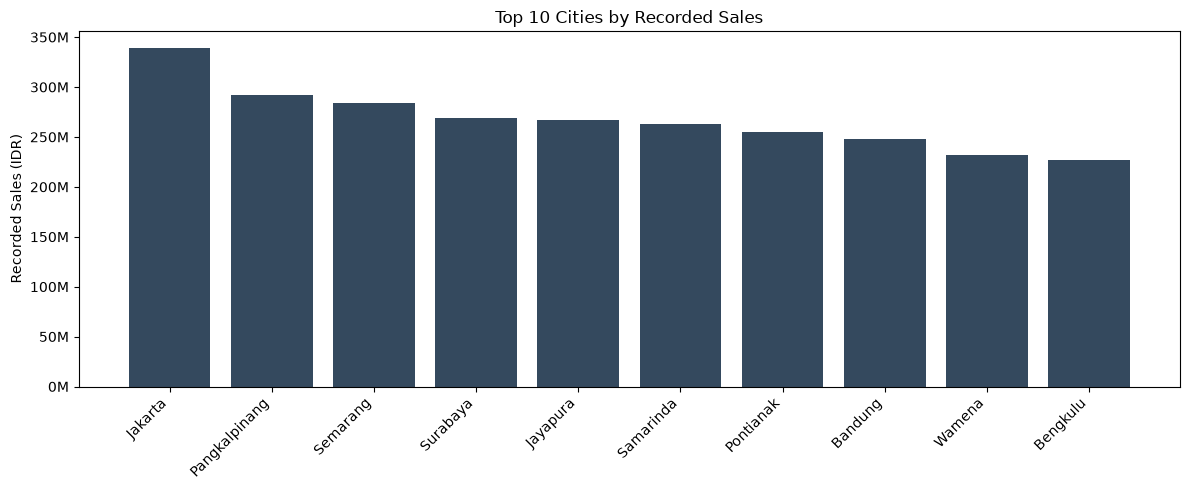

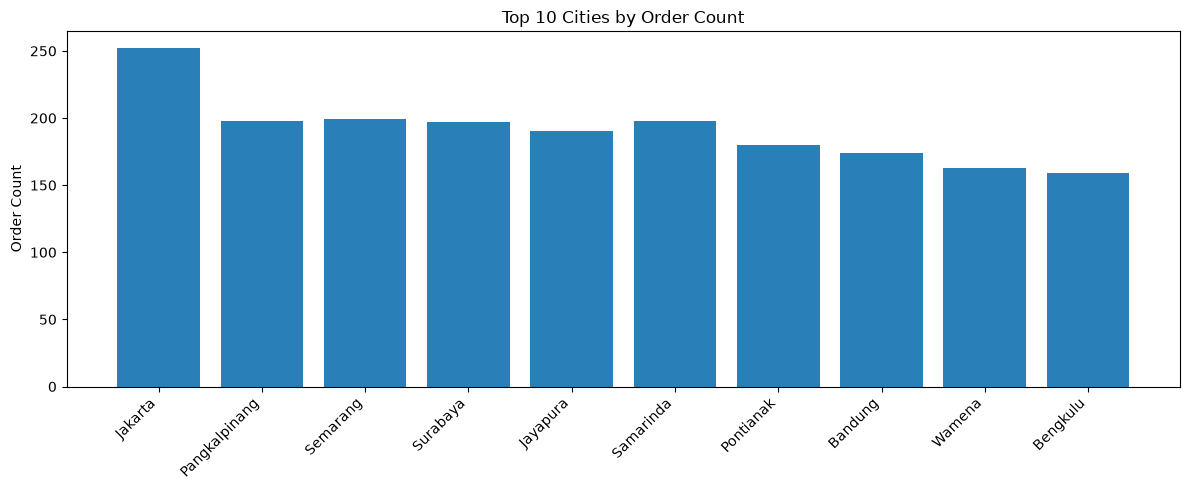

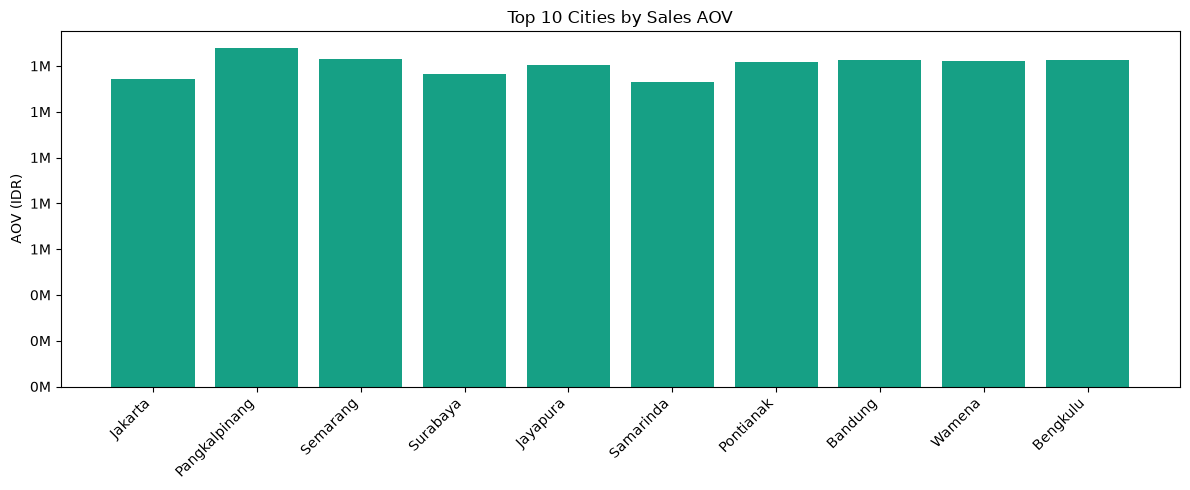

Top 3 cities account for 13.1% of total recorded sales.
For reference, an even split across all 38 cities would put 3 cities at 7.9%.

Geographic interpretation: Jakarta leads in recorded sales, but only marginally -- it holds just 4.9% of total recorded sales, and the top 3 cities combined account for 13.1% out of 38 cities. That is close to the 7.9% an even split would produce, so recorded sales are spread thinly across the city base rather than concentrated in one or two metro centers.
The cities with the highest AOV are not the cities with the highest sales volume -- Jakarta does not appear among the top-5 AOV cities -- so recorded sales leadership here reflects order volume spread across many cities, not a basket-value effect.


In [20]:
city_summary = summarize_by_dimension(order_df, 'City').rename(
    columns={'orders': 'order_count', 'total_sales': 'recorded_sales'}
)
city_summary['aov'] = (city_summary['recorded_sales'] / city_summary['order_count']).round(0)
city_summary = city_summary.sort_values('recorded_sales', ascending=False)
city_top10 = city_summary.head(10)

print('Top 10 cities by recorded sales')
display(city_top10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(city_top10['City'], city_top10['recorded_sales'], color='#34495e')
ax.set_title('Top 10 Cities by Recorded Sales')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(city_top10['City'], city_top10['order_count'], color='#2980b9')
ax.set_title('Top 10 Cities by Order Count')
ax.set_ylabel('Order Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(city_top10['City'], city_top10['aov'], color='#16a085')
ax.set_title('Top 10 Cities by Sales AOV')
ax.set_ylabel('AOV (IDR)')
rupiah_axis(ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top3_share = (
    city_summary.head(3)['recorded_sales'].sum()
    / city_summary['recorded_sales'].sum()
    * 100
)
top1_city = city_summary.iloc[0]['City']
top1_share = city_summary.iloc[0]['sales_share_pct']
n_cities = city_summary.shape[0]
even_split_top3 = 300 / n_cities  # what 3 cities would hold under a perfectly even split

print(f'Top 3 cities account for {top3_share:.1f}% of total recorded sales.')
print(f'For reference, an even split across all {n_cities} cities would put 3 cities at {even_split_top3:.1f}%.')

print(
    f'\nGeographic interpretation: {top1_city} leads in recorded sales, but only marginally -- '
    f'it holds just {top1_share:.1f}% of total recorded sales, and the top 3 cities combined '
    f'account for {top3_share:.1f}% out of {n_cities} cities. That is close to the {even_split_top3:.1f}% '
    f'an even split would produce, so recorded sales are spread thinly across the city base rather '
    f'than concentrated in one or two metro centers.'
)
print(
    'The cities with the highest AOV are not the cities with the highest sales volume -- '
    f'{top1_city} does not appear among the top-5 AOV cities -- so recorded sales leadership here '
    'reflects order volume spread across many cities, not a basket-value effect.'
)

## 11. Product Performance

This section compares products on recorded sales, quantity, and price to see whether sales leaders are also volume leaders.


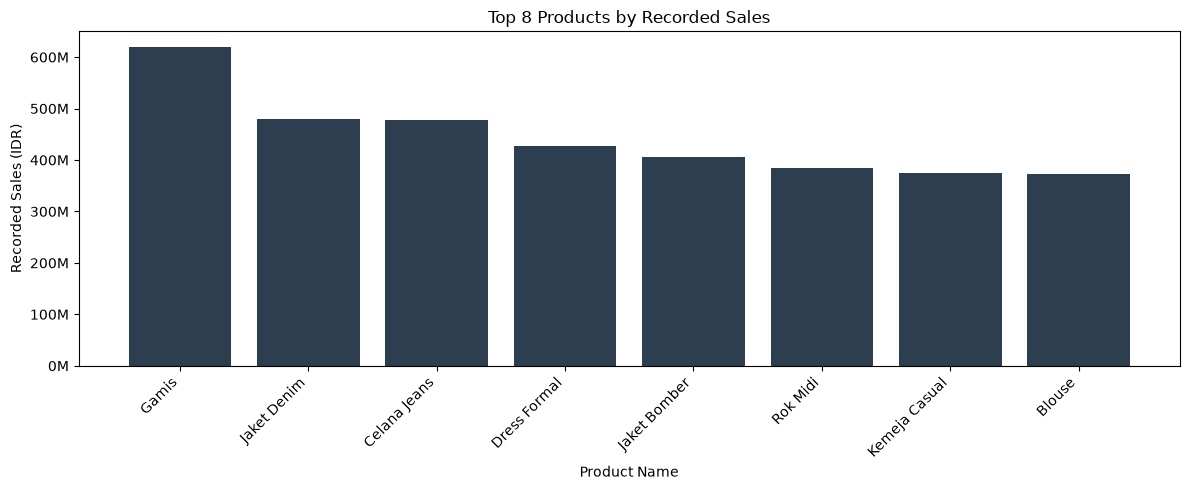

Top 8 products by recorded sales


,Product Name,total_sales,total_qty,avg_unit_price,sales_share_pct
7,Gamis,619178000,1191,518259.259259,8.876080
11,Jaket Denim,478830300,1117,431621.983914,6.864159
3,Celana Jeans,477506000,1163,413150.967742,6.845175
6,Dress Formal,427203100,716,599458.100559,6.124069
10,Jaket Bomber,406594800,1132,360915.343915,5.828644
18,Rok Midi,385007200,1375,280237.482117,5.519180
15,Kemeja Casual,375000500,1549,242690.012970,5.375731
0,Blouse,373209300,1487,251544.607190,5.350054


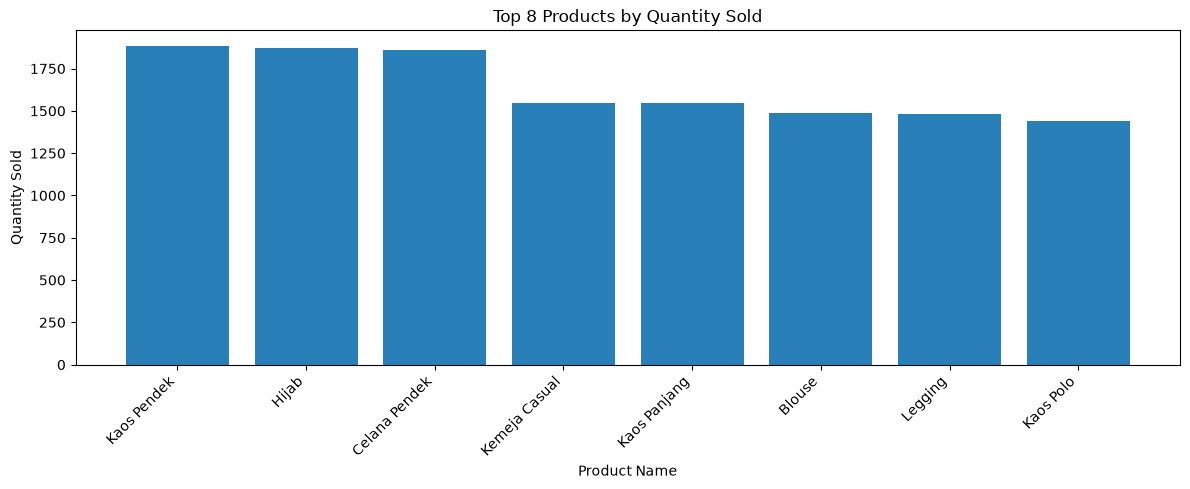

Top 8 products by quantity


,Product Name,total_sales,total_qty,avg_unit_price,sales_share_pct
13,Kaos Pendek,204052500,1882,109290.666667,2.925147
8,Hijab,172154600,1873,92429.133858,2.467882
4,Celana Pendek,321030300,1857,175229.619565,4.602054
15,Kemeja Casual,375000500,1549,242690.012970,5.375731
12,Kaos Panjang,207068500,1547,133811.464968,2.968382
0,Blouse,373209300,1487,251544.607190,5.350054
17,Legging,263072800,1483,179693.570451,3.771218
14,Kaos Polo,279674700,1441,195754.768392,4.009211


2 of the top 8 sales products are also in the top 8 quantity products.
Shared products: ['Blouse', 'Kemeja Casual']


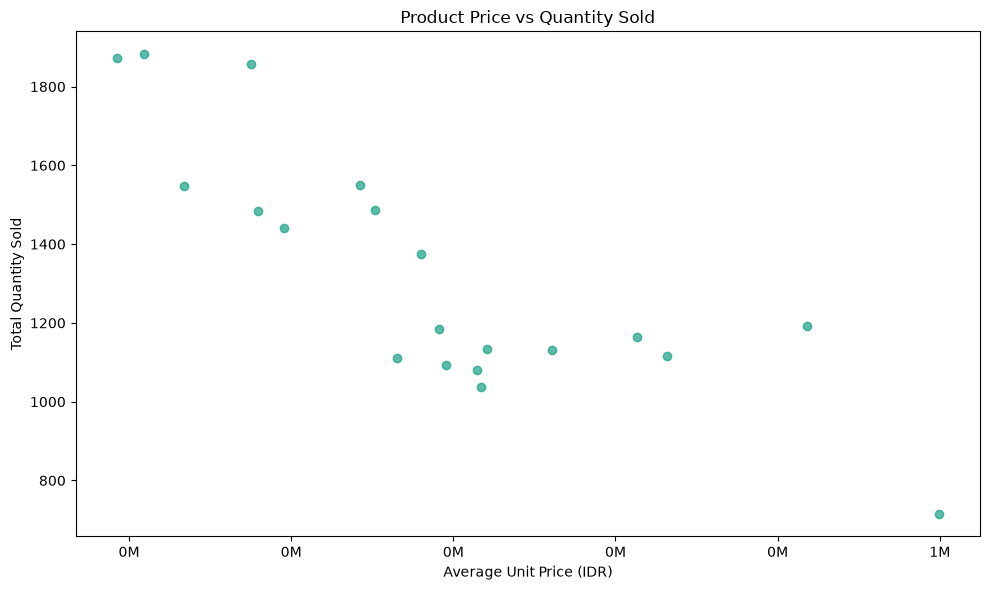

Top 5 products account for 34.5% of total recorded sales.
Top 10 products account for 60.9% of total recorded sales.


In [21]:
product_summary = df.groupby('Product Name').agg(
    total_sales=('Total Sales', 'sum'),
    total_qty=('Quantity', 'sum'),
    avg_unit_price=('Unit Price', 'mean'),
).reset_index()
product_summary['sales_share_pct'] = product_summary['total_sales'] / product_summary['total_sales'].sum() * 100
product_summary = product_summary.sort_values('total_sales', ascending=False)

# 11.1 Top products by recorded sales
N = 8
sales_leaders = product_summary.head(N)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(sales_leaders['Product Name'], sales_leaders['total_sales'], color='#2c3e50')
ax.set_title(f'Top {N} Products by Recorded Sales')
ax.set_xlabel('Product Name')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Top {N} products by recorded sales')
display(sales_leaders)

# 11.2 Top products by quantity
qty_leaders = product_summary.sort_values('total_qty', ascending=False).head(N)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(qty_leaders['Product Name'], qty_leaders['total_qty'], color='#2980b9')
ax.set_title(f'Top {N} Products by Quantity Sold')
ax.set_xlabel('Product Name')
ax.set_ylabel('Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Top {N} products by quantity')
display(qty_leaders)

# 11.3 Sales leaders vs volume leaders
shared_leaders = set(sales_leaders['Product Name']) & set(qty_leaders['Product Name'])
print(f'{len(shared_leaders)} of the top {N} sales products are also in the top {N} quantity products.')
print('Shared products:', sorted(shared_leaders))

# 11.4 Price-volume relationship
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(product_summary['avg_unit_price'], product_summary['total_qty'], alpha=0.7, color='#16a085')
ax.set_title('Product Price vs Quantity Sold')
ax.set_xlabel('Average Unit Price (IDR)')
ax.set_ylabel('Total Quantity Sold')
rupiah_axis(ax, axis='x')
plt.tight_layout()
plt.show()

# 11.5 Product sales concentration
product_summary = product_summary.sort_values('total_sales', ascending=False).reset_index(drop=True)
top5_share = product_summary.loc[:4, 'total_sales'].sum() / product_summary['total_sales'].sum() * 100
top10_share = product_summary.loc[:9, 'total_sales'].sum() / product_summary['total_sales'].sum() * 100
print(f'Top 5 products account for {top5_share:.1f}% of total recorded sales.')
print(f'Top 10 products account for {top10_share:.1f}% of total recorded sales.')


## 12. Category / Material / Gender Analysis

This section examines how category, material, and gender contribute to sales and quantity, and whether Category x Gender is a meaningful cross-dimensional split.

**Note on `Category`**: the cleaned dataset has no `Category` column -- only `Product Name` (20 distinct values), `Material`, and `Gender`. The category mix below is therefore a *derived* field, built by mapping each of the 20 products into one of five groups (Tops, Bottoms, Dresses, Outerwear, Accessories) based on product type. This is an analyst-defined taxonomy, not a field that existed in the source data, and it is flagged here so downstream sections using `Category` are read with that caveat in mind.

In [22]:
# 12.0 Derive Category from Product Name (Category does not exist in the source data)
CATEGORY_MAP = {
    'Blouse': 'Tops', 'Cardigan': 'Tops', 'Hoodie': 'Tops', 'Kaos Panjang': 'Tops',
    'Kaos Pendek': 'Tops', 'Kaos Polo': 'Tops', 'Kemeja Casual': 'Tops',
    'Kemeja Formal': 'Tops', 'Sweater': 'Tops',
    'Celana Chino': 'Bottoms', 'Celana Jeans': 'Bottoms', 'Celana Pendek': 'Bottoms',
    'Legging': 'Bottoms', 'Rok Midi': 'Bottoms',
    'Dress Casual': 'Dresses', 'Dress Formal': 'Dresses', 'Gamis': 'Dresses',
    'Jaket Bomber': 'Outerwear', 'Jaket Denim': 'Outerwear',
    'Hijab': 'Accessories',
}
df['Category'] = df['Product Name'].map(CATEGORY_MAP)
unmapped = df.loc[df['Category'].isna(), 'Product Name'].unique()
assert len(unmapped) == 0, f'Unmapped Product Name values found: {unmapped}'
print(f"Category derived for all {df['Product Name'].nunique()} products, grouped into {df['Category'].nunique()} categories.")
display(df.groupby('Category')['Product Name'].unique())

Category derived for all 20 products, grouped into 5 categories.


Category
Accessories                                              [Hijab]
Bottoms        [Rok Midi, Celana Pendek, Celana Jeans, Celana...
Dresses                      [Gamis, Dress Casual, Dress Formal]
Outerwear                            [Jaket Denim, Jaket Bomber]
Tops           [Kemeja Formal, Sweater, Kemeja Casual, Hoodie...
Name: Product Name, dtype: object

Category sales mix


,Category,total_sales,total_qty,avg_price,sales_share_pct
4,Tops,2765761600,12373,235990.736656,39.6
1,Bottoms,1766979800,6970,270222.343324,25.3
2,Dresses,1385483300,2988,477467.549669,19.9
3,Outerwear,885425100,2249,396033.288948,12.7
0,Accessories,172154600,1873,92429.133858,2.5


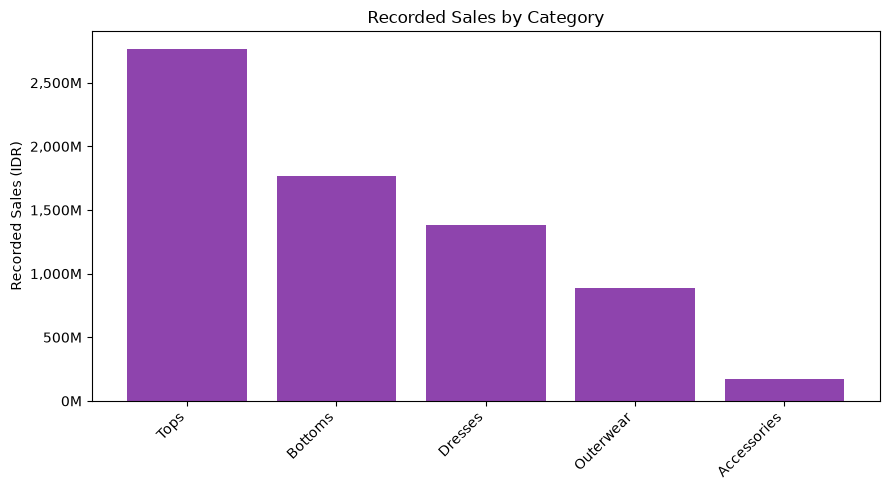

In [23]:
# 12.1 Category mix
category_summary = df.groupby('Category').agg(
    total_sales=('Total Sales', 'sum'),
    total_qty=('Quantity', 'sum'),
    avg_price=('Unit Price', 'mean'),
).reset_index().sort_values('total_sales', ascending=False)
category_summary['sales_share_pct'] = (category_summary['total_sales'] / category_summary['total_sales'].sum() * 100).round(1)
print('Category sales mix')
display(category_summary)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(category_summary['Category'], category_summary['total_sales'], color='#8e44ad')
ax.set_title('Recorded Sales by Category')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top material sales mix


,Material,total_sales,total_qty,avg_price,sales_share_pct
8,Katun,903565000,4003,242952.935468,13.0
16,Polyester,721592100,3387,229076.016500,10.3
18,Satin,489330600,1188,451694.513716,7.0
23,Sutra,356356400,636,569147.117296,5.1
24,Twill,343539900,1228,280693.121693,4.9
5,Denim,315303000,751,423059.880240,4.5
2,Chambray,276366000,856,336375.757576,4.0
4,Cotton Combed,248721500,1507,179108.355091,3.6
7,Jersey,244857600,1774,139252.631579,3.5
12,Knitted,236069800,742,320250.000000,3.4


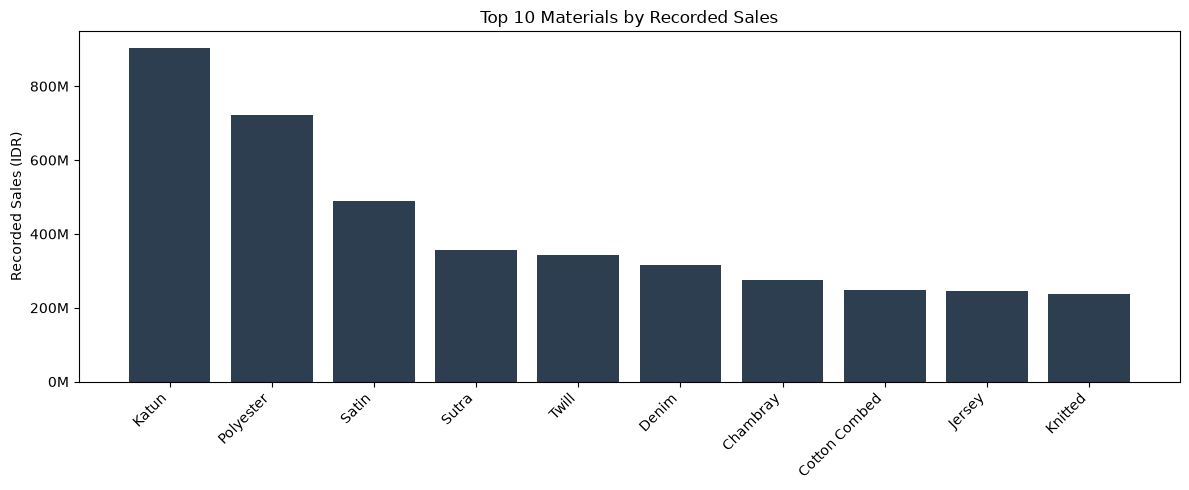

Cotton and Katun appear separately in the material mix:


,Material,total_sales,total_qty,avg_price,sales_share_pct
8,Katun,903565000,4003,242952.935468,13.0
3,Cotton,161679100,379,431047.808765,2.3


In [24]:
# 12.2 Material mix
material_summary = df.groupby('Material').agg(
    total_sales=('Total Sales', 'sum'),
    total_qty=('Quantity', 'sum'),
    avg_price=('Unit Price', 'mean'),
).reset_index().sort_values('total_sales', ascending=False)
material_summary['sales_share_pct'] = (material_summary['total_sales'] / material_summary['total_sales'].sum() * 100).round(1)
print('Top material sales mix')
display(material_summary.head(10))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(material_summary['Material'].head(10), material_summary['total_sales'].head(10), color='#2c3e50')
ax.set_title('Top 10 Materials by Recorded Sales')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
cotton_katun = material_summary[material_summary['Material'].isin(['Cotton', 'Katun'])]
if not cotton_katun.empty:
    print('Cotton and Katun appear separately in the material mix:')
    display(cotton_katun)

Gender sales mix


,Gender,total_sales,total_qty,orders,sales_share_pct
0,Pria,4070917600,16211,4689,58.4
1,Wanita,2904886800,10242,3942,41.6


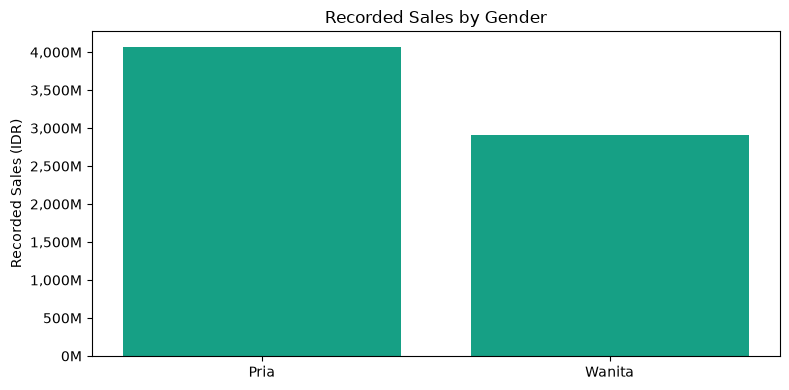

In [25]:
# 12.3 Gender mix
gender_summary = df.groupby('Gender').agg(
    total_sales=('Total Sales', 'sum'),
    total_qty=('Quantity', 'sum'),
    orders=('Order ID', 'nunique')
).reset_index().sort_values('total_sales', ascending=False)
gender_summary['sales_share_pct'] = (gender_summary['total_sales'] / gender_summary['total_sales'].sum() * 100).round(1)
print('Gender sales mix')
display(gender_summary)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(gender_summary['Gender'], gender_summary['total_sales'], color='#16a085')
ax.set_title('Recorded Sales by Gender')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax)
plt.tight_layout()
plt.show()

Recorded sales by Category x Gender (IDR)


Gender,Pria,Wanita
Category,,
Tops,2066592700,699168900
Bottoms,1118899800,648080000
Dresses,0,1385483300
Outerwear,885425100,0
Accessories,0,172154600


Within-category gender share (%)


Gender,Pria,Wanita
Category,,
Tops,74.7,25.3
Bottoms,63.3,36.7
Dresses,0.0,100.0
Outerwear,100.0,0.0
Accessories,0.0,100.0


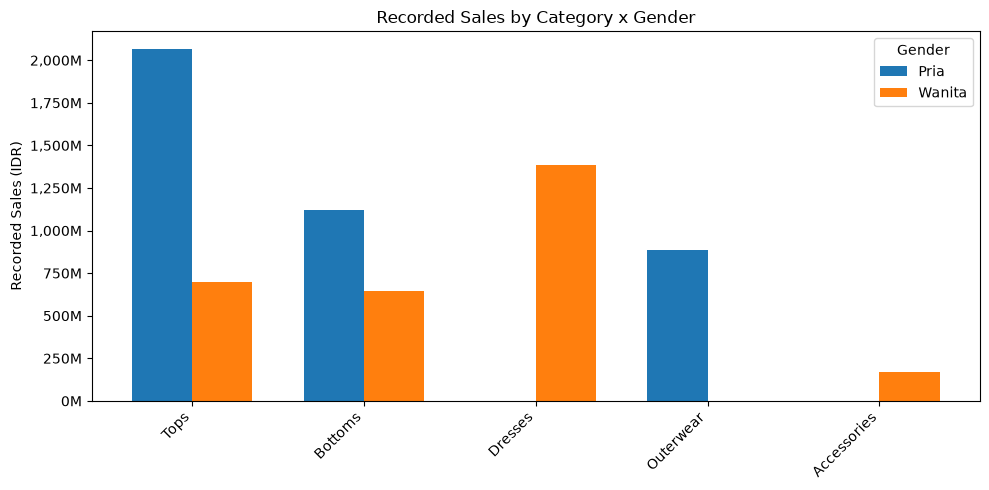

Categories where one gender holds more than 65% of category sales:


Gender,Pria,Wanita
Category,,
Tops,74.7,25.3
Dresses,0.0,100.0
Outerwear,100.0,0.0
Accessories,0.0,100.0


In [26]:
# 12.4 Category x Gender (cross-dimensional)
cat_gender_sales = df.pivot_table(index='Category', columns='Gender', values='Total Sales', aggfunc='sum', fill_value=0)
cat_gender_sales = cat_gender_sales.loc[category_summary['Category']]  # keep category rank order
cat_gender_share = (cat_gender_sales.div(cat_gender_sales.sum(axis=1), axis=0) * 100).round(1)

print('Recorded sales by Category x Gender (IDR)')
display(cat_gender_sales)
print('Within-category gender share (%)')
display(cat_gender_share)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cat_gender_sales.index))
width = 0.35
for i, gender in enumerate(cat_gender_sales.columns):
    ax.bar(x + (i - 0.5) * width, cat_gender_sales[gender], width, label=gender)
ax.set_xticks(x)
ax.set_xticklabels(cat_gender_sales.index, rotation=45, ha='right')
ax.set_title('Recorded Sales by Category x Gender')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax)
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

skew_threshold = 65.0
skewed_categories = cat_gender_share[(cat_gender_share > skew_threshold).any(axis=1)]
if not skewed_categories.empty:
    print(f'Categories where one gender holds more than {skew_threshold:.0f}% of category sales:')
    display(skewed_categories)
else:
    print(f'No category has a gender split more skewed than {skew_threshold:.0f}/{100-skew_threshold:.0f}; gender mix is broadly similar across categories.')

## 13. Customer Ratings

This section evaluates customer ratings at the order level: overall distribution, average rating by platform and status (with order counts, so a platform average is never read without its sample size), and whether rating relates to order value.

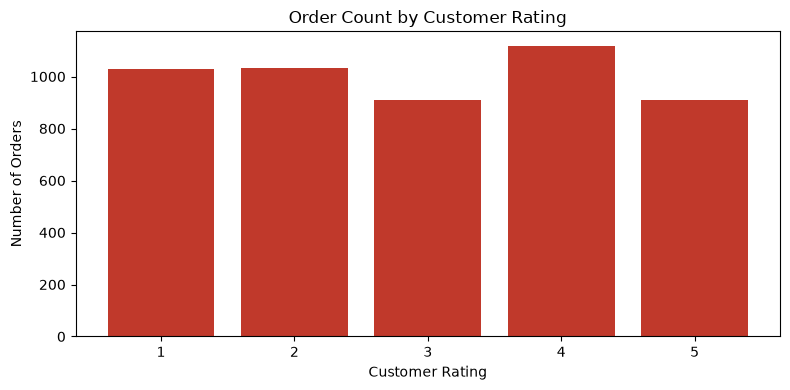

Orders with ratings of 3 or lower represent 59.4% of all orders.


In [27]:
# 13.1 Rating distribution
rating_counts = order_df['Customer_Rating'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rating_counts.index.astype(str), rating_counts.values, color='#c0392b')
ax.set_title('Order Count by Customer Rating')
ax.set_xlabel('Customer Rating')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

low_rating_share = (order_df['Customer_Rating'] <= 3).mean() * 100
print(f'Orders with ratings of 3 or lower represent {low_rating_share:.1f}% of all orders.')

In [28]:
# 13.2 Rating by platform and status, with order counts alongside the average
rating_platform = order_df.groupby('Platform').agg(
    avg_rating=('Customer_Rating', 'mean'),
    order_count=('Order ID', 'nunique'),
).reset_index().sort_values('avg_rating', ascending=False)
rating_platform['avg_rating'] = rating_platform['avg_rating'].round(3)
print('Average customer rating by platform (with order count)')
display(rating_platform)

rating_status = order_df.groupby('Order_Status').agg(
    avg_rating=('Customer_Rating', 'mean'),
    order_count=('Order ID', 'nunique'),
).reset_index().sort_values('avg_rating', ascending=False)
rating_status['avg_rating'] = rating_status['avg_rating'].round(3)
print('Average customer rating by order status (with order count)')
display(rating_status)

rating_platform_spread = rating_platform['avg_rating'].max() - rating_platform['avg_rating'].min()
print(
    f"Average rating across platforms ranges from {rating_platform['avg_rating'].min():.2f} to "
    f"{rating_platform['avg_rating'].max():.2f} (spread of {rating_platform_spread:.2f} on a 1-5 scale), "
    f"across order counts from {rating_platform['order_count'].min():,} to {rating_platform['order_count'].max():,} per platform."
)

Average customer rating by platform (with order count)


,Platform,avg_rating,order_count
0,FashionHub,3.073,455
4,Toko Fashion App,2.988,1753
1,FashionKita,2.981,1000
3,StyleMart,2.979,1134
2,OutfitNow,2.815,658


Average customer rating by order status (with order count)


,Order_Status,avg_rating,order_count
4,Shipped,3.091,263
2,Pending,3.008,242
1,Completed,2.972,3430
0,Cancelled,2.935,371
3,Returned,2.916,694


Average rating across platforms ranges from 2.81 to 3.07 (spread of 0.26 on a 1-5 scale), across order counts from 455 to 1,753 per platform.


Order value by rating


,Customer_Rating,avg_grand_total,median_grand_total,order_count
0,1,1416267.0,1359500.0,1030
1,2,1420633.0,1380000.0,1031
2,3,1410209.0,1355000.0,911
3,4,1417490.0,1355500.0,1118
4,5,1426426.0,1365500.0,910


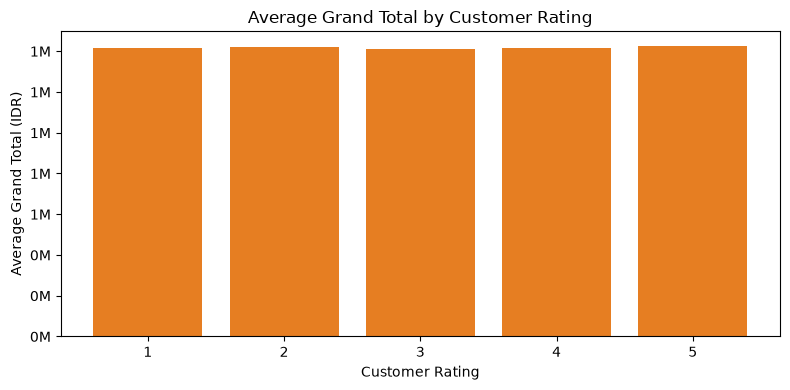

Pearson correlation between rating and order value: 0.004 -- a negligible relationship by Cohen (1988) thresholds (|r|<0.1 negligible, <0.3 weak, <0.5 moderate, >=0.5 strong).


In [29]:
# 13.3 Rating vs order value
def cohen_r_label(r: float) -> str:
    """Classify |r| using Cohen (1988) conventional thresholds: <0.1 negligible, <0.3 weak, <0.5 moderate, else strong."""
    a = abs(r)
    if a < 0.1:
        return 'negligible'
    if a < 0.3:
        return 'weak'
    if a < 0.5:
        return 'moderate'
    return 'strong'

rating_value = order_df.groupby('Customer_Rating').agg(
    avg_grand_total=('Grand_Total', 'mean'),
    median_grand_total=('Grand_Total', 'median'),
    order_count=('Order ID', 'nunique'),
).reset_index()
rating_value['avg_grand_total'] = rating_value['avg_grand_total'].round(0)
print('Order value by rating')
display(rating_value)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rating_value['Customer_Rating'].astype(str), rating_value['avg_grand_total'], color='#e67e22')
ax.set_title('Average Grand Total by Customer Rating')
ax.set_xlabel('Customer Rating')
ax.set_ylabel('Average Grand Total (IDR)')
rupiah_axis(ax)
plt.tight_layout()
plt.show()

rating_value_corr = order_df['Customer_Rating'].corr(order_df['Grand_Total'])
print(
    f'Pearson correlation between rating and order value: {rating_value_corr:.3f} '
    f'-- a {cohen_r_label(rating_value_corr)} relationship by Cohen (1988) thresholds '
    f'(|r|<0.1 negligible, <0.3 weak, <0.5 moderate, >=0.5 strong).'
)

## 14. Discount Behavior

This section measures discount incidence at two grains: **line-item** (as recorded in `df`, one row per product) and **order** (aggregated to `Order ID`, since Order Value / Quantity questions are order-level questions and mixing a line-item discount rate with `Grand Total` would compare two different grains).

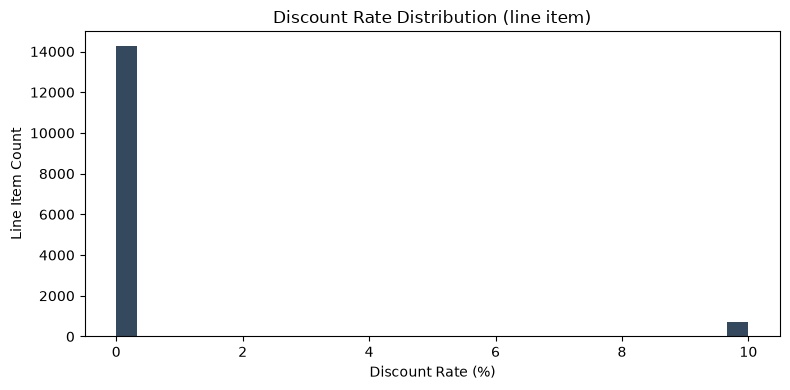

Average discount rate by platform (line item)


,Platform,discount_rate
0,FashionHub,0.005852
1,FashionKita,0.005631
2,OutfitNow,0.005146
4,Toko Fashion App,0.004626
3,StyleMart,0.003762


Average discount rate by category (line item)


,Category,discount_rate
3,Outerwear,0.005326
2,Dresses,0.005254
4,Tops,0.004676
1,Bottoms,0.004632
0,Accessories,0.004593


In [30]:
# 14.1 Line-item discount rate: distribution, by platform, by category
df_temp = df.assign(discount_rate=df['Discount Amount'] / df['Subtotal'].replace(0, np.nan))
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_temp['discount_rate'].dropna() * 100, bins=30, color='#34495e')
ax.set_title('Discount Rate Distribution (line item)')
ax.set_xlabel('Discount Rate (%)')
ax.set_ylabel('Line Item Count')
plt.tight_layout()
plt.show()

discount_platform = df_temp.groupby('Platform')['discount_rate'].mean().reset_index().sort_values('discount_rate', ascending=False)
print('Average discount rate by platform (line item)')
display(discount_platform)

discount_category = df_temp.groupby('Category')['discount_rate'].mean().reset_index().sort_values('discount_rate', ascending=False)
print('Average discount rate by category (line item)')
display(discount_category)

In [31]:
# 14.2 Build order-level discount rate and attach it to order_df
order_discount = df.groupby('Order ID').agg(
    order_discount_amount=('Discount Amount', 'sum'),
    order_subtotal=('Subtotal', 'sum'),
).reset_index()
order_discount['order_discount_rate'] = order_discount['order_discount_amount'] / order_discount['order_subtotal'].replace(0, np.nan)
order_df = order_df.merge(order_discount[['Order ID', 'order_discount_rate']], on='Order ID', how='left')
print('order-level discount rate attached to order_df:')
display(order_df[['Order ID', 'order_discount_rate', 'Quantity', 'Grand_Total']].head(3))

order-level discount rate attached to order_df:


,Order ID,order_discount_rate,Quantity,Grand_Total
0,ORD00001,0.0,4,883000
1,ORD00002,0.0,5,2228000
2,ORD00003,0.0,4,2122000


Units per order by order-level discount bucket


,discount_bucket,avg_quantity,order_count
0,0%,5.293549,4759
1,5-10%,5.232365,241


Grand Total by order-level discount bucket


,discount_bucket,avg_grand_total,order_count
0,0%,1424532.0,4759
1,5-10%,1292861.0,241


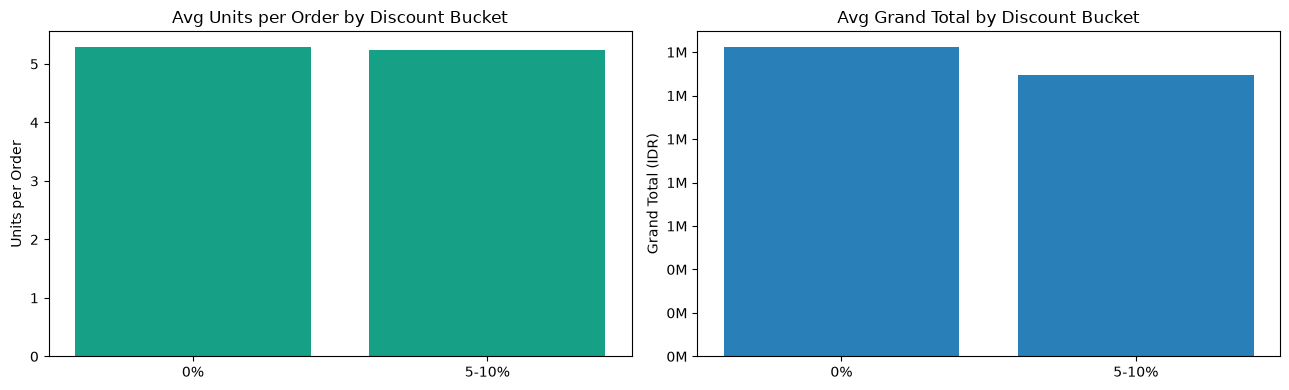

Order-level correlation, discount rate vs quantity: -0.007 (negligible).
Order-level correlation, discount rate vs Grand Total: -0.050 (negligible).


In [32]:
# 14.3 Discount vs Quantity and Discount vs Order Value (order-level, not mixed with line-item rate)
discount_bins = [-0.001, 0, 0.05, 0.10, 0.15, 1.0]
discount_labels = ['0%', '0-5%', '5-10%', '10-15%', '15%+']
order_df['discount_bucket'] = pd.cut(order_df['order_discount_rate'].fillna(0), bins=discount_bins, labels=discount_labels)

discount_vs_qty = order_df.groupby('discount_bucket', observed=True).agg(
    avg_quantity=('Quantity', 'mean'),
    order_count=('Order ID', 'nunique'),
).reset_index()
print('Units per order by order-level discount bucket')
display(discount_vs_qty)

discount_vs_value = order_df.groupby('discount_bucket', observed=True).agg(
    avg_grand_total=('Grand_Total', 'mean'),
    order_count=('Order ID', 'nunique'),
).reset_index()
discount_vs_value['avg_grand_total'] = discount_vs_value['avg_grand_total'].round(0)
print('Grand Total by order-level discount bucket')
display(discount_vs_value)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(discount_vs_qty['discount_bucket'].astype(str), discount_vs_qty['avg_quantity'], color='#16a085')
axes[0].set_title('Avg Units per Order by Discount Bucket')
axes[0].set_ylabel('Units per Order')
axes[1].bar(discount_vs_value['discount_bucket'].astype(str), discount_vs_value['avg_grand_total'], color='#2980b9')
axes[1].set_title('Avg Grand Total by Discount Bucket')
axes[1].set_ylabel('Grand Total (IDR)')
rupiah_axis(axes[1])
plt.tight_layout()
plt.show()

order_discount_qty_corr = order_df['order_discount_rate'].corr(order_df['Quantity'])
order_discount_value_corr = order_df['order_discount_rate'].corr(order_df['Grand_Total'])
print(
    f'Order-level correlation, discount rate vs quantity: {order_discount_qty_corr:.3f} '
    f'({cohen_r_label(order_discount_qty_corr)}).'
)
print(
    f'Order-level correlation, discount rate vs Grand Total: {order_discount_value_corr:.3f} '
    f'({cohen_r_label(order_discount_value_corr)}).'
)

## 15. Order Economics

This section reviews order-size economics at the order level: Grand Total distribution, units per order, **line items per order** (distinct from units -- an order can carry 3 line items totalling 5 units), shipping fee, order-level discount behavior, and whether a small share of orders drives a large share of revenue.

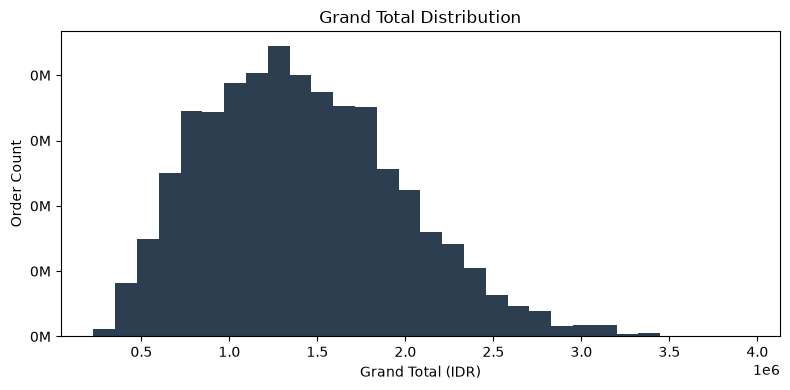

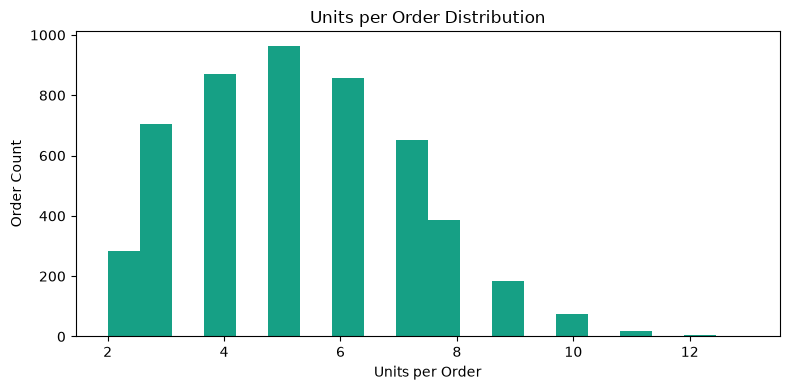

Top 10% of orders by value represent 17.6% of total recorded sales.


,Grand_Total,Quantity
count,5000.0,5000.0
mean,1418186.0,5.0
std,560582.0,2.0
min,227000.0,2.0
25%,993000.0,4.0
50%,1365950.0,5.0
75%,1784250.0,7.0
max,3943000.0,13.0


In [33]:
# 15.1 Grand Total and units-per-order distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(order_df['Grand_Total'].dropna(), bins=30, color='#2c3e50')
ax.set_title('Grand Total Distribution')
ax.set_xlabel('Grand Total (IDR)')
ax.set_ylabel('Order Count')
rupiah_axis(ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(order_df['Quantity'].dropna(), bins=20, color='#16a085')
ax.set_title('Units per Order Distribution')
ax.set_xlabel('Units per Order')
ax.set_ylabel('Order Count')
plt.tight_layout()
plt.show()

high_value_sales_share = order_df.loc[order_df['Grand_Total'] >= order_df['Grand_Total'].quantile(0.9), 'Grand_Total'].sum() / order_df['Grand_Total'].sum() * 100
print(f'Top 10% of orders by value represent {high_value_sales_share:.1f}% of total recorded sales.')
display(order_df[['Grand_Total', 'Quantity']].describe().round(0))

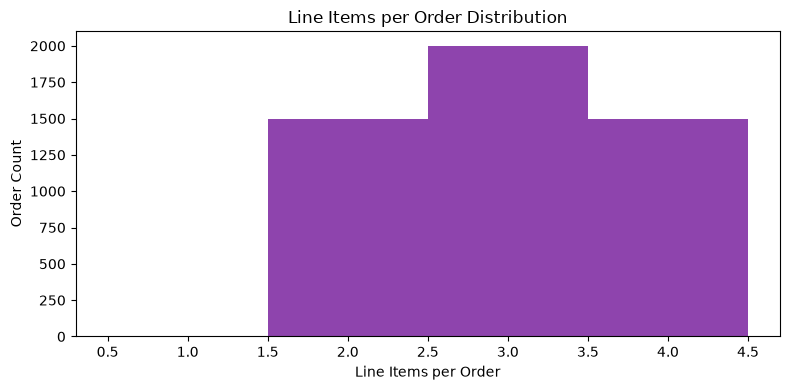

100.0% of orders contain more than one line item. On average, each line item carries 1.76 units -- so a typical multi-item order (e.g. 3 line items) is not just '3 units', it is closer to 5.3 units across 3 different products.


,order_count,avg_quantity
Line_Items,,
2,1500,3.51
3,2000,5.32
4,1500,7.04


In [34]:
# 15.2 Line items per order (distinct from units per order)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(order_df['Line_Items'].dropna(), bins=range(1, int(order_df['Line_Items'].max()) + 2), color='#8e44ad', align='left')
ax.set_title('Line Items per Order Distribution')
ax.set_xlabel('Line Items per Order')
ax.set_ylabel('Order Count')
plt.tight_layout()
plt.show()

avg_units_per_line_item = order_df['Quantity'].sum() / order_df['Line_Items'].sum()
multi_item_share = (order_df['Line_Items'] > 1).mean() * 100
print(
    f"{multi_item_share:.1f}% of orders contain more than one line item. On average, each line item "
    f"carries {avg_units_per_line_item:.2f} units -- so a typical multi-item order (e.g. 3 line items) "
    f"is not just '3 units', it is closer to {3 * avg_units_per_line_item:.1f} units across 3 different products."
)
display(order_df.groupby('Line_Items').agg(order_count=('Order ID', 'nunique'), avg_quantity=('Quantity', 'mean')).round(2))

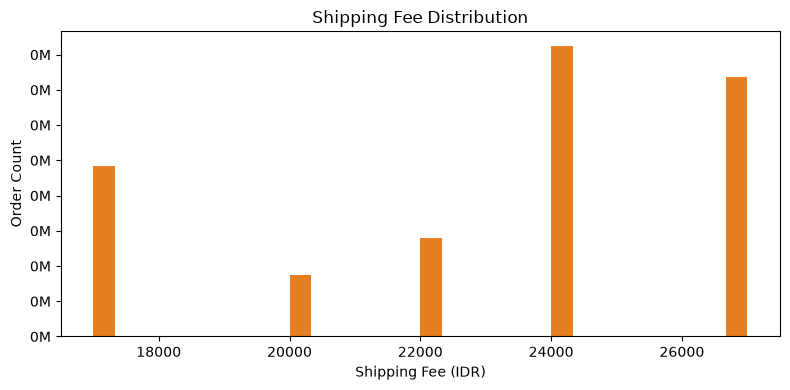

count     5000.0
mean     23025.0
std       3570.0
min      17000.0
25%      20000.0
50%      24000.0
75%      27000.0
max      27000.0
Name: Shipping_Fee, dtype: float64

In [35]:
# 15.3 Shipping fee distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(order_df['Shipping_Fee'].dropna(), bins=30, color='#e67e22')
ax.set_title('Shipping Fee Distribution')
ax.set_xlabel('Shipping Fee (IDR)')
ax.set_ylabel('Order Count')
rupiah_axis(ax)
plt.tight_layout()
plt.show()
display(order_df['Shipping_Fee'].describe().round(0))

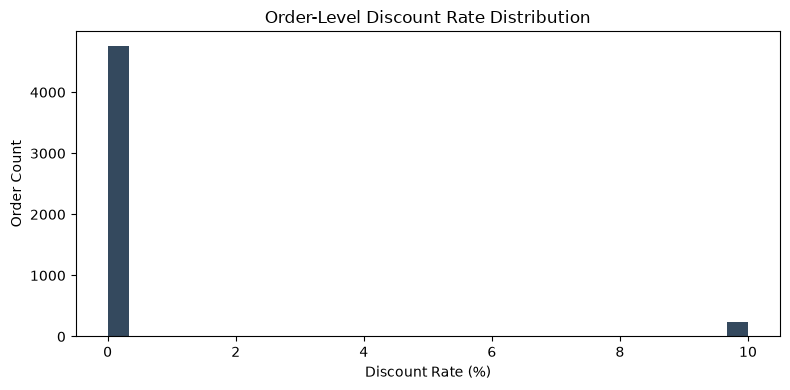

95.2% of orders have no discount at all at the order level.


count    5000.0000
mean        0.0048
std         0.0214
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         0.1000
Name: order_discount_rate, dtype: float64

In [36]:
# 15.4 Order-level discount behavior
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(order_df['order_discount_rate'].fillna(0) * 100, bins=30, color='#34495e')
ax.set_title('Order-Level Discount Rate Distribution')
ax.set_xlabel('Discount Rate (%)')
ax.set_ylabel('Order Count')
plt.tight_layout()
plt.show()

zero_discount_share = (order_df['order_discount_rate'].fillna(0) == 0).mean() * 100
print(f'{zero_discount_share:.1f}% of orders have no discount at all at the order level.')
display(order_df['order_discount_rate'].describe().round(4))

## 16. Cross-Dimensional Review

Section 9-15 each looked at one dimension at a time. This section combines dimensions to answer three specific questions: is platform performance volume-driven or basket-driven, are top products winning on volume or price, and does discount rate actually move AOV at the platform level.

In [37]:
# 16.1 Platform Economics: volume vs basket-value
platform_econ = platform_summary[['Platform', 'order_count', 'recorded_sales', 'aov', 'avg_units_per_order']].merge(
    platform_discount[['Platform', 'avg_discount_rate']], on='Platform'
).sort_values('recorded_sales', ascending=False)
print('Platform economics: volume, AOV, units/order, discount -- side by side')
display(platform_econ)

volume_vs_sales_corr = platform_econ['order_count'].corr(platform_econ['recorded_sales'])
aov_vs_sales_corr = platform_econ['aov'].corr(platform_econ['recorded_sales'])
n_platforms = len(platform_econ)
print(
    f'Across {n_platforms} platforms: correlation(order_count, recorded_sales) = {volume_vs_sales_corr:.3f} '
    f'({cohen_r_label(volume_vs_sales_corr)}); correlation(AOV, recorded_sales) = {aov_vs_sales_corr:.3f} '
    f'({cohen_r_label(aov_vs_sales_corr)}). With only {n_platforms} platforms these correlations are '
    f'directional, not statistically robust, but the relative magnitude still indicates which lever tracks '
    f'sales more closely: {"order volume" if abs(volume_vs_sales_corr) > abs(aov_vs_sales_corr) else "AOV"}.'
)

Platform economics: volume, AOV, units/order, discount -- side by side


,Platform,order_count,recorded_sales,aov,avg_units_per_order,avg_discount_rate
0,Toko Fashion App,1753,2459498600,1403023.0,NaN,0.0046
1,StyleMart,1134,1550422300,1367215.0,NaN,0.0038
2,FashionKita,1000,1414191200,1414191.0,NaN,0.0056
3,OutfitNow,658,923708300,1403812.0,NaN,0.0051
4,FashionHub,455,627984000,1380185.0,NaN,0.0059


Across 5 platforms: correlation(order_count, recorded_sales) = 1.000 (strong); correlation(AOV, recorded_sales) = 0.218 (weak). With only 5 platforms these correlations are directional, not statistically robust, but the relative magnitude still indicates which lever tracks sales more closely: order volume.


In [38]:
# 16.2 Product Economics: volume-driven or price-driven?
product_econ = product_summary[['Product Name', 'total_qty', 'avg_unit_price', 'total_sales']].sort_values('total_sales', ascending=False)
print('Top products: quantity, price, and sales side by side')
display(product_econ.head(10))

qty_vs_sales_corr = product_summary['total_qty'].corr(product_summary['total_sales'])
price_vs_sales_corr = product_summary['avg_unit_price'].corr(product_summary['total_sales'])
print(
    f'Across all {len(product_summary)} products: correlation(quantity, sales) = {qty_vs_sales_corr:.3f} '
    f'({cohen_r_label(qty_vs_sales_corr)}); correlation(avg unit price, sales) = {price_vs_sales_corr:.3f} '
    f'({cohen_r_label(price_vs_sales_corr)}). '
    f'{"Quantity" if abs(qty_vs_sales_corr) > abs(price_vs_sales_corr) else "Price"} tracks recorded sales '
    f'more closely across the product catalog.'
)

Top products: quantity, price, and sales side by side


,Product Name,total_qty,avg_unit_price,total_sales
0,Gamis,1191,518259.259259,619178000
1,Jaket Denim,1117,431621.983914,478830300
2,Celana Jeans,1163,413150.967742,477506000
3,Dress Formal,716,599458.100559,427203100
4,Jaket Bomber,1132,360915.343915,406594800
5,Rok Midi,1375,280237.482117,385007200
6,Kemeja Casual,1549,242690.012970,375000500
7,Blouse,1487,251544.607190,373209300
8,Sweater,1135,321061.760841,363508300
9,Hoodie,1184,291092.568449,342955700


Across all 20 products: correlation(quantity, sales) = -0.565 (strong); correlation(avg unit price, sales) = 0.864 (strong). Price tracks recorded sales more closely across the product catalog.


Hypothesis: platforms that discount more heavily also have higher AOV.


,Platform,avg_discount_rate,aov
4,FashionHub,0.0059,1380185.0
2,FashionKita,0.0056,1414191.0
3,OutfitNow,0.0051,1403812.0
0,Toko Fashion App,0.0046,1403023.0
1,StyleMart,0.0038,1367215.0


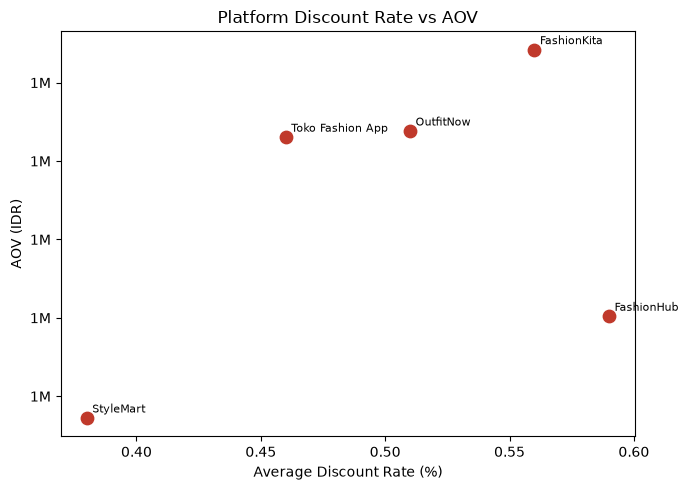

Correlation(avg discount rate, AOV) across 5 platforms = 0.453 (moderate). This supports the hypothesis that heavier discounting is associated with higher AOV at the platform level (n is small, so treat this as directional).


In [39]:
# 16.3 Hypothesis-driven: does a higher platform discount rate come with a higher AOV?
platform_discount_aov = platform_econ[['Platform', 'avg_discount_rate', 'aov']].sort_values('avg_discount_rate', ascending=False)
print('Hypothesis: platforms that discount more heavily also have higher AOV.')
display(platform_discount_aov)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(platform_discount_aov['avg_discount_rate'] * 100, platform_discount_aov['aov'], s=80, color='#c0392b')
for _, row in platform_discount_aov.iterrows():
    ax.annotate(row['Platform'], (row['avg_discount_rate'] * 100, row['aov']), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Average Discount Rate (%)')
ax.set_ylabel('AOV (IDR)')
rupiah_axis(ax)
ax.set_title('Platform Discount Rate vs AOV')
plt.tight_layout()
plt.show()

discount_aov_corr = platform_discount_aov['avg_discount_rate'].corr(platform_discount_aov['aov'])
print(
    f'Correlation(avg discount rate, AOV) across {len(platform_discount_aov)} platforms = {discount_aov_corr:.3f} '
    f'({cohen_r_label(discount_aov_corr)}). '
    f'{"This supports" if discount_aov_corr > 0.3 else "This does not support"} the hypothesis that heavier '
    f'discounting is associated with higher AOV at the platform level (n is small, so treat this as directional).'
)

## 17. Key Findings

Findings are generated directly from the values computed above (Sections 9-16) rather than written as free-text judgments, so every claim below is traceable to a printed number in this notebook.

In [40]:
# 17.1 Key findings, generated from computed values above
print('KEY FINDINGS')
print('=' * 60)

print(
    f"1. Platform sales leadership: order_count vs recorded_sales correlation is {volume_vs_sales_corr:.3f} "
    f"({cohen_r_label(volume_vs_sales_corr)}) vs AOV vs recorded_sales correlation of {aov_vs_sales_corr:.3f} "
    f"({cohen_r_label(aov_vs_sales_corr)}) across {n_platforms} platforms -- order volume tracks sales more "
    f"closely than AOV does."
)

print(
    f"2. City concentration: the top 3 cities account for {top3_share:.1f}% of total recorded sales out of "
    f"{n_cities} cities; an even split across all {n_cities} cities would put 3 cities at {even_split_top3:.1f}%. "
    f"The single top city ({top1_city}) holds {top1_share:.1f}% of recorded sales."
)

print(
    f"3. Product concentration: the top 5 products account for {top5_share:.1f}% of recorded sales, and the top "
    f"10 account for {top10_share:.1f}%, out of {len(product_summary)} products. Quantity vs sales correlation "
    f"is {qty_vs_sales_corr:.3f} ({cohen_r_label(qty_vs_sales_corr)}) and price vs sales correlation is "
    f"{price_vs_sales_corr:.3f} ({cohen_r_label(price_vs_sales_corr)})."
)

print(
    f"4. Discount behavior: order-level discount rate vs quantity correlation is {order_discount_qty_corr:.3f} "
    f"({cohen_r_label(order_discount_qty_corr)}); vs Grand Total is {order_discount_value_corr:.3f} "
    f"({cohen_r_label(order_discount_value_corr)}). At the platform level, discount rate vs AOV correlation is "
    f"{discount_aov_corr:.3f} ({cohen_r_label(discount_aov_corr)}) across {len(platform_discount_aov)} platforms."
)

print(
    f"5. Customer ratings: platform averages range from {rating_platform['avg_rating'].min():.2f} to "
    f"{rating_platform['avg_rating'].max():.2f} (spread of {rating_platform_spread:.2f} on a 1-5 scale), across "
    f"order counts from {rating_platform['order_count'].min():,} to {rating_platform['order_count'].max():,}. "
    f"Rating vs order value correlation is {rating_value_corr:.3f} ({cohen_r_label(rating_value_corr)}), so "
    f"rating and order value show {cohen_r_label(rating_value_corr)} linear association -- sales differences "
    f"are better explained by volume and product mix than by rating gaps."
)

print(
    f"6. Category x Gender: {len(skewed_categories)} of {len(cat_gender_share)} categories have a gender split "
    f"more skewed than {skew_threshold:.0f}/{100-skew_threshold:.0f}."
)

print(
    f"7. Order structure: {multi_item_share:.1f}% of orders contain more than one line item, averaging "
    f"{avg_units_per_line_item:.2f} units per line item. {zero_discount_share:.1f}% of orders carry no discount "
    f"at the order level. Top 10% of orders by value account for {high_value_sales_share:.1f}% of total "
    f"recorded sales."
)

KEY FINDINGS
1. Platform sales leadership: order_count vs recorded_sales correlation is 1.000 (strong) vs AOV vs recorded_sales correlation of 0.218 (weak) across 5 platforms -- order volume tracks sales more closely than AOV does.
2. City concentration: the top 3 cities account for 13.1% of total recorded sales out of 38 cities; an even split across all 38 cities would put 3 cities at 7.9%. The single top city (Jakarta) holds 4.9% of recorded sales.
3. Product concentration: the top 5 products account for 34.5% of recorded sales, and the top 10 account for 60.9%, out of 20 products. Quantity vs sales correlation is -0.565 (strong) and price vs sales correlation is 0.864 (strong).
4. Discount behavior: order-level discount rate vs quantity correlation is -0.007 (negligible); vs Grand Total is -0.050 (negligible). At the platform level, discount rate vs AOV correlation is 0.453 (moderate) across 5 platforms.
5. Customer ratings: platform averages range from 2.81 to 3.07 (spread of 0.26 

**Reading note**: correlation strength labels above follow Cohen (1988) conventional thresholds (|r| < 0.1 negligible, < 0.3 weak, < 0.5 moderate, >= 0.5 strong) and are stated alongside the correlation coefficient every time, not used as a stand-alone adjective.

## 18. Questions for Business Insights

- What explains the AOV differences between platforms, given that platform sales leadership appears largely volume-driven?
- Are high-discount transactions concentrated in particular categories or materials?
- Which products combine high sales with strong or weak quantity performance?
- Are non-completed orders disproportionately concentrated in specific platforms or cities?
- Does product or material mix explain why certain cities and platforms perform better in recorded sales?


## 19. Next Steps

EDA
↓
Validated Patterns
↓
Business Questions
↓
Business Insights
↓
Power BI Dashboard

The next phase should translate these validated patterns into business implications and priorities, including which metrics and filters a dashboard should surface. This notebook stops at evidence and questions rather than making recommendations.
